# Section 1 : Setting up HugginFace - Importing basics and Login.

In [1]:
import os
HF_TOKEN = os.getenv("HF_TOKEN")

In [2]:
from huggingface_hub import login
login(token=HF_TOKEN)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
!hf auth whoami

user:  RonnieSDas


"https://huggingface.co/spaces/mrdbourke/trashify_demo_v4" - Final Project Demo looks like the one below:

In [4]:
from IPython.display import HTML 

HTML("""
<iframe
    src="https://mrdbourke-trashify-demo-v4.hf.space"
    frameborder="0"
    width="850"
    height="1150"
></iframe>
""")

In [5]:
import datasets
import gradio as gr
import torchmetrics 
import pycocotools
import random
import numpy as np
import torch
import transformers
from pprint import pprint


#Check package versions:
print(f"USING VERSIONS - \ttransformers : {transformers.__version__}, \t datasets : {datasets.__version__}, \t torch : {torch.__version__}, \t torchmetrics : {torchmetrics.__version__}")

USING VERSIONS - 	transformers : 5.2.0, 	 datasets : 4.5.0, 	 torch : 2.5.1+cu121, 	 torchmetrics : 1.8.2


NOTE: A tool for drawing boxes on images for object boundary detection is [Prodigy](https://prodi.gy/features/computer-vision)

# Section 2 :  Loading the dataset

In [6]:
from datasets import load_dataset
# load_dataset? #Basic class definition

In [7]:
dataset = load_dataset(path = "mrdbourke/trashify_manual_labelled_images")
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 1128
    })
})

In [8]:
print(dataset['train']) # type(dataset) -> datasets.dataset_dict.DatasetDict | isinstance(dataset, datasets.dataset_dict.DatasetDict) -> True
type(dataset)

Dataset({
    features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
    num_rows: 1128
})


datasets.dataset_dict.DatasetDict

In [9]:
# Understanding the datatype of the dataset and how to access it. Comment and execute to see specific parts
print(dataset['train'], type(dataset['train']), '\n')

pprint(dataset['train'].features)
print("type of dataset['train'].features ", type(dataset['train'].features), '\n')

pprint(dataset['train'].features['annotations'])
print("type of dataset['train'].features['annotations'] ", type(dataset['train'].features['annotations']), '\n')

pprint(dataset['train'].features['annotations']['category_id'])
print("type of dataset['train'].features['annotations']['category_id'] ", type(dataset['train'].features['annotations']['category_id']), '\n')

pprint(dataset['train'].features['annotations']['category_id'].feature)
print("type of dataset['train'].features['annotations']['category_id'].feature ", type(dataset['train'].features['annotations']['category_id'].feature), '\n')

pprint(dataset['train'].features['annotations']['category_id'].feature.names)
print("type of dataset['train'].features['annotations']['category_id'].feature.names ", type(dataset['train'].features['annotations']['category_id'].feature.names), '\n')

Dataset({
    features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
    num_rows: 1128
}) <class 'datasets.arrow_dataset.Dataset'> 

{'annotations': {'area': List(Value('float32')),
                 'bbox': List(List(Value('float32'), length=4)),
                 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
                 'file_name': List(Value('string')),
                 'image_id': List(Value('int64')),
                 'iscrowd': List(Value('int64'))},
 'image': Image(mode=None, decode=True),
 'image_id': Value('int64'),
 'image_source': Value('string'),
 'label_source': Value('string')}
type of dataset['train'].features  <class 'datasets.features.features.Features'> 

{'area': List(Value('float32')),
 'bbox': List(List(Value('float32'), length=4)),
 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
 'file_name': List(Valu

In [10]:
pprint(dataset['train'][0]) #Viewing a sample's features

{'annotations': {'area': [135381.078125, 1039532.4375],
                 'bbox': [[523.7000122070312,
                           545.0999755859375,
                           402.79998779296875,
                           336.1000061035156],
                          [10.399999618530273,
                           163.6999969482422,
                           943.4000244140625,
                           1101.9000244140625]],
                 'category_id': [1, 0],
                 'file_name': ['00347467-13f1-4cb9-94aa-4e4369457e0c.jpeg',
                               '00347467-13f1-4cb9-94aa-4e4369457e0c.jpeg'],
                 'image_id': [292, 292],
                 'iscrowd': [0, 0]},
 'image': <PIL.Image.Image image mode=RGB size=960x1280 at 0x76DCEB5C5AF0>,
 'image_id': 292,
 'image_source': 'manual_taken_photo',
 'label_source': 'manual_prodigy_label'}


In [11]:
print(type(dataset['train'].features))
pprint(dataset['train'].features) #Viewing all samples' features

<class 'datasets.features.features.Features'>
{'annotations': {'area': List(Value('float32')),
                 'bbox': List(List(Value('float32'), length=4)),
                 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
                 'file_name': List(Value('string')),
                 'image_id': List(Value('int64')),
                 'iscrowd': List(Value('int64'))},
 'image': Image(mode=None, decode=True),
 'image_id': Value('int64'),
 'image_source': Value('string'),
 'label_source': Value('string')}


In [12]:
print(type(dataset['train'].features['annotations']))
pprint(dataset['train'].features['annotations']) # Accessing a specific key in the 'dataset["train"]' dict.
print('\n', type(dataset['train'].features['annotations'])) # Turns out each key is a dict as well. A nested dict structure.
print('\n', dataset['train'].features['annotations'].keys()) # Set of all keys inside the dict 'annotations' which happens to be a key of the dict 'dataset['train']'
print('\n', dataset['train'].features['annotations']['area']) # Accessing a specific key in the 'annotations' dict.

<class 'dict'>
{'area': List(Value('float32')),
 'bbox': List(List(Value('float32'), length=4)),
 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
 'file_name': List(Value('string')),
 'image_id': List(Value('int64')),
 'iscrowd': List(Value('int64'))}

 <class 'dict'>

 dict_keys(['file_name', 'image_id', 'category_id', 'bbox', 'iscrowd', 'area'])

 List(Value('float32'))


In [13]:
dataset['train'][2]['annotations']['bbox'][0] # This array gives us the coordinates of a single bounding box in the format XYWH.

[349.5, 677.2000122070312, 210.89999389648438, 376.0]

X is the x-coordinate of the top left corner of the box (349.5). \
Y is the y-coordinate of the top left corner of the box (677.2000122070312).\
W is the width of the box (210.89999389648438).\
H is the height of the box (376.0).

In [14]:
categories = dataset['train'].features['annotations']['category_id']
print(type(categories), dir(categories), "\n")
print(type(categories.feature), "\n")
print(categories)
print(categories.feature)
print(categories.feature.names)

<class 'datasets.features.features.List'> ['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', '_type', 'feature', 'id', 'length', 'pa_type'] 

<class 'datasets.features.features.ClassLabel'> 

List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']))
ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])
['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']


In [15]:
# Creating a mapping from numbers to labels
id2label = {i:class_name for i, class_name in enumerate(categories.feature.names)}
print(id2label.items())
label2id = {value:key for key, value in id2label.items()}
print(label2id.items())

dict_items([(0, 'bin'), (1, 'hand'), (2, 'not_bin'), (3, 'not_hand'), (4, 'not_trash'), (5, 'trash'), (6, 'trash_arm')])
dict_items([('bin', 0), ('hand', 1), ('not_bin', 2), ('not_hand', 3), ('not_trash', 4), ('trash', 5), ('trash_arm', 6)])


In [16]:
# Creating a colour palette
# Make colour dictionary
colour_palette = {
    'bin': (0, 0, 224),         # Bright Blue (High contrast with greenery) in format (red, green, blue)
    'not_bin': (255, 80, 80),   # Light Red to indicate negative class

    'hand': (148, 0, 211),      # Dark Purple (Contrasts well with skin tones)
    'not_hand': (255, 80, 80),  # Light Red to indicate negative class

    'trash': (0, 255, 0),       # Bright Green (For trash-related items)
    'not_trash': (255, 80, 80), # Light Red to indicate negative class

    'trash_arm': (255, 140, 0), # Deep Orange (Highly visible)
}

pprint(colour_palette)

{'bin': (0, 0, 224),
 'hand': (148, 0, 211),
 'not_bin': (255, 80, 80),
 'not_hand': (255, 80, 80),
 'not_trash': (255, 80, 80),
 'trash': (0, 255, 0),
 'trash_arm': (255, 140, 0)}


We’ll just have to write a small function to normalize our colour values from [0, 255] to [0, 1] \
 (matplotlib expects our colour values to be between 0 and 1).


[('bin', (0.0, 0.0, 0.8784313725490196)),
 ('not_bin', (1.0, 0.3137254901960784, 0.3137254901960784)),
 ('hand', (0.5803921568627451, 0.0, 0.8274509803921568)),
 ('not_hand', (1.0, 0.3137254901960784, 0.3137254901960784)),
 ('trash', (0.0, 1.0, 0.0)),
 ('not_trash', (1.0, 0.3137254901960784, 0.3137254901960784)),
 ('trash_arm', (1.0, 0.5490196078431373, 0.0))]

 <class 'list'>


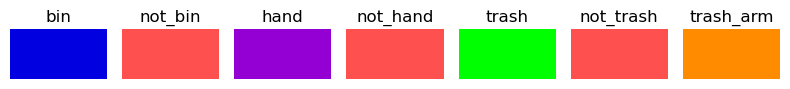

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Normalize RGB values between 0-1 range:
def normalize_rgb(rgb_tuple):
    return tuple(x/255 for x in rgb_tuple)

# Turn colors into normalized RGB values for matplotlib
colors_and_labels_rgb  = [(key, normalize_rgb(value)) for (key, value) in colour_palette.items()]
pprint(colors_and_labels_rgb) 
print('\n',type(colors_and_labels_rgb))

# Create figure and axis
fig, ax = plt.subplots(1, 7, figsize = (8,1))

# Flatten the axis array for easier iteration
ax = ax.flatten()

# Plot each color square
for idx, (label, color) in enumerate(colors_and_labels_rgb):
    ax[idx].add_patch(plt.Rectangle(xy=(0, 0), 
                                    width=1, 
                                    height=1, 
                                    facecolor=color))
    ax[idx].set_title(label)
    ax[idx].set_xlim(0, 1)
    ax[idx].set_ylim(0, 1)
    ax[idx].axis('off')

plt.tight_layout()
plt.show()

# Section 3 : Plotting an image from the loaded dataset and visualizing the bounding boxes

In [18]:
# To make the images fit in the notebook window, it is important to create a function to make them smaller

import PIL

def half_image(image: PIL.Image) -> PIL.Image:
    """
    Resizes a given input image by half and returns the smaller version.
    """
    return image.resize(size=(image.size[0] // 2, image.size[1] // 2))

def half_boxes(boxes):
    """
    Halves an array/tensor of input boxes and returns them. Necessary for plotting them on a half-sized image.

    For example:

    boxes = [100, 100, 100, 100]
    half_boxes = half_boxes(boxes)
    print(half_boxes)

    >>> [50, 50, 50, 50]
    """
    if isinstance(boxes, list):
        # If boxes are list of lists, then we have multiple boxes
        for box in boxes:
            if isinstance(box, list):
                return [[coordinate // 2 for coordinate in box] for box in boxes]
            else:
                return [coordinate // 2 for coordinate in boxes]         
    
    if isinstance(boxes, np.ndarray):
        return (boxes // 2)
    
    if isinstance(boxes, torch.Tensor):
        return (boxes // 2)

# Test the functions 
image_test = dataset["train"][42]["image"]
image_test_half = half_image(image_test)
print(f"[INFO] Original image size: {image_test.size} | Half image size: {image_test_half.size}")

boxes_test_list = [100, 100, 100, 100]
print(f"[INFO] Original boxes: {boxes_test_list} | Half boxes: {half_boxes(boxes_test_list)}")

boxes_test_torch = torch.tensor([100.0, 100.0, 100.0, 100.0])
print(f"[INFO] Original boxes: {boxes_test_torch} | Half boxes: {half_boxes(boxes_test_torch)}")


[INFO] Original image size: (960, 1280) | Half image size: (480, 640)
[INFO] Original boxes: [100, 100, 100, 100] | Half boxes: [50, 50, 50, 50]
[INFO] Original boxes: tensor([100., 100., 100., 100.]) | Half boxes: tensor([50., 50., 50., 50.])


Plotting boxes on a single image step by step

[INFO] Showing training sample from index: 950 - 
Boxes in XYWH format: tensor([[131., 230., 147., 193.],
        [128., 188., 259., 338.],
        [ 16., 176., 140., 248.],
        [  7., 318., 197., 286.]])
Boxes in XYXY format: tensor([[131., 230., 278., 423.],
        [128., 188., 387., 526.],
        [ 16., 176., 156., 424.],
        [  7., 318., 204., 604.]])

Label names: ['trash', 'bin', 'bin', 'hand']
Colour codes: [(0, 255, 0), (0, 0, 224), (0, 0, 224), (148, 0, 211)]


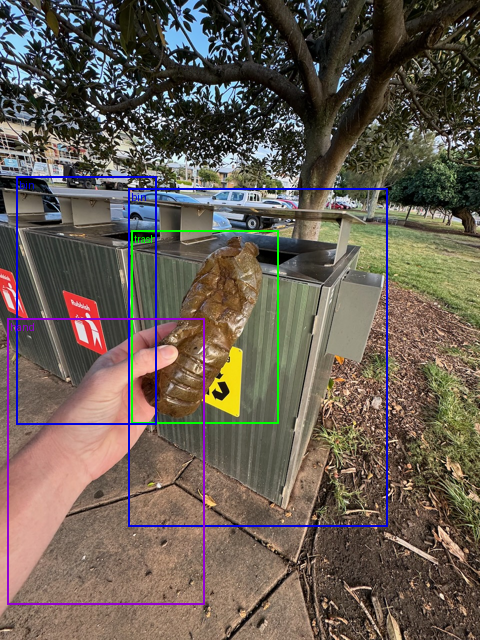

In [19]:
import random
import torch
from torchvision.ops import box_convert
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import pil_to_tensor, to_pil_image

# Step 1 : Select a random sample from the loaded dataset
random_index = random.randint(0, len(dataset['train']))
random_sample = dataset['train'][random_index]
print(f"[INFO] Showing training sample from index: {random_index} - ")

# Step 2 : Get image and boxes from random_sample
random_sample_image = random_sample['image']
random_sample_boxes = random_sample['annotations']['bbox']  
# Optional: Half the image and boxes for space saving (all of the following code will work with/without half size images)
half_random_sample_image = half_image(random_sample_image)
half_random_sample_boxes = half_boxes(random_sample_boxes)

# Step 3. Turn box coordinates in a tensor
boxes_xywh = torch.tensor(half_random_sample_boxes)
print(f"Boxes in XYWH format: {boxes_xywh}")

# Step 4. Convert coordinates from XYWH to XYXY (since torchvision.utils.draw_bounding_boxes requires input boxes in XYXY format (X_min, y_min, X_max, y_max))
boxes_xyxy = box_convert(boxes = boxes_xywh, in_fmt = 'xywh', out_fmt = 'xyxy')
print(f"Boxes in XYXY format: {boxes_xyxy}\n")

# Step 5. Get label names of target boxes and colours to match
random_sample_label_names = [categories.feature.names[x] for x in random_sample["annotations"]["category_id"]] 
random_sample_colours = [colour_palette[label] for label in random_sample_label_names]
print(f"Label names: {random_sample_label_names}")
print(f"Colour codes: {random_sample_colours}")

# Step 6. Converting half_random_sample_image from pil to tensor in order to use draw_bounding_boxes, then after the boxes are drawn on the image, using to_pil_image to plot the image with the bboxes drawn on it
to_pil_image(
    pic = draw_bounding_boxes(
        image = pil_to_tensor(pic = half_random_sample_image),
        boxes = boxes_xyxy,
        colors = random_sample_colours,
        labels = random_sample_label_names,
        width = 2,
        # label_colors = random_sample_colours
    )
)


In [20]:
# Re-Understanding the datatype of the dataset and how to access it.
print(dataset['train'], type(dataset['train']), '\n')

pprint(dataset['train'].features)
print("type of dataset['train'].features ", type(dataset['train'].features), '\n')

pprint(dataset['train'].features['annotations'])
print("type of dataset['train'].features['annotations'] ", type(dataset['train'].features['annotations']), '\n')

Dataset({
    features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
    num_rows: 1128
}) <class 'datasets.arrow_dataset.Dataset'> 

{'annotations': {'area': List(Value('float32')),
                 'bbox': List(List(Value('float32'), length=4)),
                 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
                 'file_name': List(Value('string')),
                 'image_id': List(Value('int64')),
                 'iscrowd': List(Value('int64'))},
 'image': Image(mode=None, decode=True),
 'image_id': Value('int64'),
 'image_source': Value('string'),
 'label_source': Value('string')}
type of dataset['train'].features  <class 'datasets.features.features.Features'> 

{'area': List(Value('float32')),
 'bbox': List(List(Value('float32'), length=4)),
 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
 'file_name': List(Valu

In [21]:
pprint(dataset['train'].features['annotations']['category_id'])
print("type of dataset['train'].features['annotations']['category_id'] ", type(dataset['train'].features['annotations']['category_id']), '\n')

pprint(dataset['train'].features['annotations']['category_id'].feature)
print("type of dataset['train'].features['annotations']['category_id'].feature ", type(dataset['train'].features['annotations']['category_id'].feature), '\n')

pprint(dataset['train'].features['annotations']['category_id'].feature.names)
print("type of dataset['train'].features['annotations']['category_id'].feature.names ", type(dataset['train'].features['annotations']['category_id'].feature.names), '\n')

List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']))
type of dataset['train'].features['annotations']['category_id']  <class 'datasets.features.features.List'> 

ClassLabel(names=['bin',
                  'hand',
                  'not_bin',
                  'not_hand',
                  'not_trash',
                  'trash',
                  'trash_arm'])
type of dataset['train'].features['annotations']['category_id'].feature  <class 'datasets.features.features.ClassLabel'> 

['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']
type of dataset['train'].features['annotations']['category_id'].feature.names  <class 'list'> 



# Section 4 : Creating the model

In [22]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="torch.nn.modules.module")  # turn off warnings for loading the model (feel free to comment this if you want to see the warnings)

from transformers import AutoModelForObjectDetection
# help(AutoModelForObjectDetection)

MODEL_NAME = "PekingU/rtdetr_v2_r50vd"

model = AutoModelForObjectDetection.from_pretrained(
    pretrained_model_name_or_path = MODEL_NAME,
    label2id = label2id,
    id2label = id2label,
    ignore_mismatched_sizes = True     # Original model was trained with a different number of output classes to ours
                                       # So we'll ignore any mismatched sizes (e.g. 91 vs. 7)
)

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

RTDetrV2ForObjectDetection LOAD REPORT from: PekingU/rtdetr_v2_r50vd
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([7, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([8, 256])
model.enc_sco

In [23]:
model, type(model)

(RTDetrV2ForObjectDetection(
   (model): RTDetrV2Model(
     (backbone): RTDetrV2ConvEncoder(
       (model): RTDetrResNetBackbone(
         (embedder): RTDetrResNetEmbeddings(
           (embedder): Sequential(
             (0): RTDetrResNetConvLayer(
               (convolution): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
               (normalization): RTDetrV2FrozenBatchNorm2d()
               (activation): ReLU()
             )
             (1): RTDetrResNetConvLayer(
               (convolution): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
               (normalization): RTDetrV2FrozenBatchNorm2d()
               (activation): ReLU()
             )
             (2): RTDetrResNetConvLayer(
               (convolution): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
               (normalization): RTDetrV2FrozenBatchNorm2d()
               (activation): ReLU()
             )
         

In [24]:
print(f"[INFO] Final classification layer: {model.class_embed}\n") # 7 output classes
print(f"[INFO] Final box regression layer: {model.bbox_embed}") # 4 boundary box coordinates

[INFO] Final classification layer: ModuleList(
  (0-5): 6 x Linear(in_features=256, out_features=7, bias=True)
)

[INFO] Final box regression layer: ModuleList(
  (0-5): 6 x RTDetrV2MLPPredictionHead(
    (layers): ModuleList(
      (0-1): 2 x Linear(in_features=256, out_features=256, bias=True)
      (2): Linear(in_features=256, out_features=4, bias=True)
    )
  )
)


In [25]:
#List only public callables
import inspect

[name for name, obj in inspect.getmembers(model) 
 if callable(obj) and not name.startswith("_")]

# help(model)

['active_adapters',
 'add_adapter',
 'add_model_tags',
 'add_module',
 'apply',
 'base_model',
 'bbox_embed',
 'bfloat16',
 'buffers',
 'can_generate',
 'children',
 'class_embed',
 'compile',
 'config_class',
 'cpu',
 'create_extended_attention_mask_for_decoder',
 'cuda',
 'delete_adapter',
 'dequantize',
 'disable_adapters',
 'disable_input_require_grads',
 'double',
 'enable_adapters',
 'enable_input_require_grads',
 'enable_peft_hotswap',
 'eval',
 'extra_repr',
 'float',
 'forward',
 'from_pretrained',
 'get_adapter_state_dict',
 'get_buffer',
 'get_compiled_call',
 'get_correct_attn_implementation',
 'get_correct_experts_implementation',
 'get_decoder',
 'get_encoder',
 'get_expanded_tied_weights_keys',
 'get_extended_attention_mask',
 'get_extra_state',
 'get_init_context',
 'get_input_embeddings',
 'get_memory_footprint',
 'get_output_embeddings',
 'get_parameter',
 'get_parameter_or_buffer',
 'get_position_embeddings',
 'get_submodule',
 'gradient_checkpointing_disable',
 'gra

In [26]:
print(model.config) # model configurations like hyperparameters and stuff

for name, param in model.named_parameters(): # all model parameters
    print(name, type(name), param.shape, type(param), param.numel())


RTDetrV2Config {
  "activation_dropout": 0.0,
  "activation_function": "silu",
  "anchor_image_size": null,
  "architectures": [
    "RtDetrV2ForObjectDetection"
  ],
  "attention_dropout": 0.0,
  "auxiliary_loss": true,
  "backbone": null,
  "backbone_config": {
    "depths": [
      3,
      4,
      6,
      3
    ],
    "downsample_in_bottleneck": false,
    "downsample_in_first_stage": false,
    "dtype": "float32",
    "embedding_size": 64,
    "hidden_act": "relu",
    "hidden_sizes": [
      256,
      512,
      1024,
      2048
    ],
    "layer_type": "bottleneck",
    "model_type": "rt_detr_resnet",
    "num_channels": 3,
    "out_features": [
      "stage2",
      "stage3",
      "stage4"
    ],
    "out_indices": [
      2,
      3,
      4
    ],
    "stage_names": [
      "stem",
      "stage1",
      "stage2",
      "stage3",
      "stage4"
    ]
  },
  "batch_norm_eps": 1e-05,
  "box_noise_scale": 1.0,
  "d_model": 256,
  "decoder_activation_function": "relu",
  "deco

In [27]:
for p in model.parameters():
    print(p.shape, ' | ', type(p), ' | ', p.numel(), ' | ', p.requires_grad)

torch.Size([32, 3, 3, 3])  |  <class 'torch.nn.parameter.Parameter'>  |  864  |  True
torch.Size([32, 32, 3, 3])  |  <class 'torch.nn.parameter.Parameter'>  |  9216  |  True
torch.Size([64, 32, 3, 3])  |  <class 'torch.nn.parameter.Parameter'>  |  18432  |  True
torch.Size([256, 64, 1, 1])  |  <class 'torch.nn.parameter.Parameter'>  |  16384  |  True
torch.Size([64, 64, 1, 1])  |  <class 'torch.nn.parameter.Parameter'>  |  4096  |  True
torch.Size([64, 64, 3, 3])  |  <class 'torch.nn.parameter.Parameter'>  |  36864  |  True
torch.Size([256, 64, 1, 1])  |  <class 'torch.nn.parameter.Parameter'>  |  16384  |  True
torch.Size([64, 256, 1, 1])  |  <class 'torch.nn.parameter.Parameter'>  |  16384  |  True
torch.Size([64, 64, 3, 3])  |  <class 'torch.nn.parameter.Parameter'>  |  36864  |  True
torch.Size([256, 64, 1, 1])  |  <class 'torch.nn.parameter.Parameter'>  |  16384  |  True
torch.Size([64, 256, 1, 1])  |  <class 'torch.nn.parameter.Parameter'>  |  16384  |  True
torch.Size([64, 64, 3

In [28]:
# Counting the total number of parameters in the loaded model (trainable / frozen):
def count_parameters(model):
    trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_parameters = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    total_parameters = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_parameters:,}")
    print(f"Trainable parameters (will be updated): {trainable_parameters:,}")
    print(f"Non-trainable parameters (will not be updated): {non_trainable_parameters:,}")

count_parameters(model)

Total parameters: 42,741,357
Trainable parameters (will be updated): 42,741,357
Non-trainable parameters (will not be updated): 0


Creating a function to build a model

In [29]:
from transformers import AutoModelForObjectDetection

def create_model(pretrained_model_name_or_path: str = MODEL_NAME,
                 label2id: dict = label2id,
                 id2label: dict = id2label) -> AutoModelForObjectDetection:
    """Creates and returns an instance of AutoModelForObjectDetection.
    
    Args: 
        pretrained_model_name_or_path (str): The name or path of the pretrained model to load. 
            Defaults to MODEL_NAME.
        label2id (dict): A dictionary mapping class labels to IDs. Defaults to label2id.
        id2label (dict): A dictionary mapping class IDs to labels. Defaults to id2label.
    
    Returns:
        AutoModelForObjectDetection: A pretrained model for object detection with number of output
            classes equivalent to len(label2id).
    """
    model = AutoModelForObjectDetection.from_pretrained(pretrained_model_name_or_path = pretrained_model_name_or_path,
                                        label2id = label2id,
                                        id2label = id2label,
                                        ignore_mismatched_sizes = True)
    return model

In [30]:
model = create_model()

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

RTDetrV2ForObjectDetection LOAD REPORT from: PekingU/rtdetr_v2_r50vd
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([7, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([8, 256])
model.enc_sco

Trying to pass a single sample through the model

In [31]:
model.forward?

Signature:
model.forward(
    pixel_values: torch.FloatTensor,
    pixel_mask: torch.LongTensor | None = None,
    encoder_outputs: torch.FloatTensor | None = None,
    inputs_embeds: torch.FloatTensor | None = None,
    labels: list[dict] | None = None,
    **kwargs: Unpack[transformers.utils.generic.TransformersKwargs],
) -> tuple[torch.FloatTensor] | transformers.models.rt_detr_v2.modeling_rt_detr_v2.RTDetrV2ObjectDetectionOutput
Docstring:
The [`RTDetrV2ForObjectDetection`] forward method, overrides the `__call__` special method.

<Tip>

Although the recipe for forward pass needs to be defined within this function, one should call the [`Module`]
instance afterwards instead of this since the former takes care of running the pre and post processing steps while
the latter silently ignores them.

</Tip>

Args:
    pixel_values (`torch.FloatTensor` of shape `(batch_size, num_channels, image_size, image_size)`):
        The tensors corresponding to the input images. Pixel values can be o

In [32]:
# # Trying to do a single forward pass through the model
# random_sample_outputs = model(pixel_values = random_sample['image'], pixel_mask = None)
# random_sample_outputs = model(pixel_values = random_sample['image'], pixel_mask = None)


 It seems I've tried to pass a PIL.Image to our model rather than a torch.FloatTensor of shape (batch_size, num_channels, height, width). \
 It looks like the input data might require some preprocessing before we can pass it to our model.

# Section 5 : Processor to Model Pattern

<!-- ![Preprocessing Pipeline](/home/suhdas/development/research/DL_Backbone_Implementations/Object_Detection_with_HF_Transformers/images_ipynb/image.png) -->
<div style="text-align: center;">
  <img src="/home/suhdas/development/research/DL_Backbone_Implementations/Object_Detection_with_HF_Transformers/images_ipynb/image.png" alt="Centered image" width="900" height="400">
</div>

Start with images labelled with boxes of trash, bin and hand (and other classes), preprocess the images to be ready for use with a model and then train the model on the preprocessed custom data. 

In [33]:
# # Example Preprocess to Inference pipeline:

# from transformers import AutoProcessor, AutoModel

# # Load raw data
# raw_data = load_data()

# # Define target model name
# MODEL_NAME = "..."

# # Load preprocessor and model (these two are often paired)
# preprocessor = AutoProcessor.from_pretrained(MODEL_NAME)
# model = AutoModel.from_pretrained(MODEL_NAME)

# # Preprocess data
# preprocessed_data = preprocessor.preprocess(raw_data)

# # Pass preprocessed data to model
# output = model(preprocessed_data)

# Section 6 : Loading the model's Preprocessor

In [34]:
from transformers import AutoImageProcessor

MODEL_NAME = "PekingU/rtdetr_v2_r50vd" # MODEL_NAME = "facebook/detr-resnet-50" # Could also use this model as an another experiment

# Loading the image processor
image_processor = AutoImageProcessor.from_pretrained(pretrained_model_name_or_path=MODEL_NAME,
                                                     use_fast=True) # load the fast version of the processor

image_processor

RTDetrImageProcessorFast {
  "data_format": "channels_first",
  "do_convert_annotations": true,
  "do_normalize": false,
  "do_pad": false,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "RTDetrImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 640,
    "width": 640
  }
}

One of the first things to see is the image_processor is expecting the bounding boxes to be in COCO format (see the "format": coco_detection field, this is the default).\
Another thing to notice is that the input images will be resized to the values of the size parameter.\ 

do_convert_annotations=True - This is the default and it will convert the boxes to the format CXCYWH or (center_x, center_y, width, height)\
size - We’ll update the size dictionary so all of our images have "longest_edge": 640 and "shortest_edge: 640"\
do_pad=True - Make sure to pad our images with 0 pixels so that all images in the same batch have the same size. For example if an image has the dimensions image_1 = (640, 480) but the largest image in the batch is (640, 640), image_1 will be padded with 0 to have its dimensions equal (640, 640). This will only happen during batch processing rather than individual image processing. See the do_pad parameter documentation for more.

In [35]:
# Set image size
IMAGE_SIZE = 640 # we could try other sizes here: 300x300, 480x480, 512x512, 640x640, 800x800 (best to experiment and see which works best)

# Create a new instance of the image processor with the desired image size
image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path=MODEL_NAME,
    use_fast=True, # use the fast preprocessor
    format="coco_detection", # this is the default
    do_convert_annotations=True, # defaults to True, converts boxes to (center_x, center_y, width, height) in range [0, 1]
    size={"shortest_edge": IMAGE_SIZE, 
          "longest_edge": IMAGE_SIZE},
    return_segmentation_masks=True,
    do_pad=True # make sure all images have 640x640 size thanks to padding
)

image_processor.size, type(image_processor.size), image_processor.size.keys()

({'shortest_edge': 640, 'longest_edge': 640},
 dict,
 dict_keys(['shortest_edge', 'longest_edge']))

In [36]:
image_processor

RTDetrImageProcessorFast {
  "data_format": "channels_first",
  "do_convert_annotations": true,
  "do_normalize": false,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "RTDetrImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "return_segmentation_masks": true,
  "size": {
    "longest_edge": 640,
    "shortest_edge": 640
  }
}

In [37]:
# # Try to process a single image and annotation pair (spoiler: this will error)
# random_sample_preprocessed = image_processor.preprocess(images = random_sample['image'],
#                                                         annotations = random_sample['annotations'])

It turns out that the annotations aren’t in the format that the preprocess method was expecting.\
Since the pre-trained model was trained on the COCO dataset, the preprocess method expects input data to be in line with the COCO format.\
TODO : Fix this later on by adjusting the annotations.\
Try to preprocess just a single image instead.

In [38]:
# Preprocess the target sample
random_sample_preprocessed_image_only = image_processor(images=random_sample["image"], # here random sample is one random sample from the entire dataset.
                                                        annotations=None, # no annotations this time 
                                                        masks_path=None, # no masks inputs
                                                        return_tensors="pt") # return as PyTorch tensors
print(type(random_sample_preprocessed_image_only)) 
print(random_sample_preprocessed_image_only.keys()) #random_sample_preprocessed_image_only

<class 'transformers.image_processing_base.BatchFeature'>
KeysView({'pixel_mask': tensor([[[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]]), 'pixel_values': tensor([[[[0.5059, 0.6275, 0.4745,  ..., 0.1294, 0.2235, 0.2000],
          [0.3882, 0.6353, 0.5373,  ..., 0.2275, 0.2039, 0.1176],
          [0.3804, 0.4196, 0.6471,  ..., 0.1490, 0.1333, 0.1137],
          ...,
          [0.5529, 0.4980, 0.4392,  ..., 0.3098, 0.3137, 0.2314],
          [0.5216, 0.4980, 0.3961,  ..., 0.2510, 0.2902, 0.2392],
          [0.6000, 0.5490, 0.5216,  ..., 0.2353, 0.3294, 0.2510]],

         [[0.7922, 0.8314, 0.6549,  ..., 0.0980, 0.1922, 0.1686],
          [0.5843, 0.8196, 0.7098,  ..., 0.2000, 0.1804, 0.0941],
          [0.4941, 0.5569, 0.8000,  ..., 0.1255, 0.1137, 0.0941],
          ...,
          [0.4588, 0.4078, 0.3529,  ..., 0.2549, 

In [39]:
random_sample_preprocessed_image_only['pixel_mask'], random_sample_preprocessed_image_only.pixel_values

(tensor([[[1, 1, 1,  ..., 1, 1, 1],
          [1, 1, 1,  ..., 1, 1, 1],
          [1, 1, 1,  ..., 1, 1, 1],
          ...,
          [1, 1, 1,  ..., 1, 1, 1],
          [1, 1, 1,  ..., 1, 1, 1],
          [1, 1, 1,  ..., 1, 1, 1]]]),
 tensor([[[[0.5059, 0.6275, 0.4745,  ..., 0.1294, 0.2235, 0.2000],
           [0.3882, 0.6353, 0.5373,  ..., 0.2275, 0.2039, 0.1176],
           [0.3804, 0.4196, 0.6471,  ..., 0.1490, 0.1333, 0.1137],
           ...,
           [0.5529, 0.4980, 0.4392,  ..., 0.3098, 0.3137, 0.2314],
           [0.5216, 0.4980, 0.3961,  ..., 0.2510, 0.2902, 0.2392],
           [0.6000, 0.5490, 0.5216,  ..., 0.2353, 0.3294, 0.2510]],
 
          [[0.7922, 0.8314, 0.6549,  ..., 0.0980, 0.1922, 0.1686],
           [0.5843, 0.8196, 0.7098,  ..., 0.2000, 0.1804, 0.0941],
           [0.4941, 0.5569, 0.8000,  ..., 0.1255, 0.1137, 0.0941],
           ...,
           [0.4588, 0.4078, 0.3529,  ..., 0.2549, 0.2627, 0.1843],
           [0.4235, 0.4078, 0.3098,  ..., 0.1882, 0.2314, 0.1

It looks like the preprocess method works on a single image.\
And it seems like we get a dictionary output with the following keys:\
    **pixel_values** - the processed pixel values of the input image.\
    (Optional) **pixel_mask** - a mask multiplier for the pixel values as to whether they should be paid attention to or not (a value of 0 means the pixel value should be ignored by the model and a value of 1 means the pixel value should be paid attention to by the model)

In [40]:
print(f"[INFO] Original image shape: {random_sample['image'].size} -> [width, height]")
print(f"[INFO] Preprocessed image shape: {random_sample_preprocessed_image_only['pixel_values'].shape} -> [batch_size, colour_channles, height, width] \n")

print(random_sample_preprocessed_image_only["pixel_values"][0])

[INFO] Original image shape: (960, 1280) -> [width, height]
[INFO] Preprocessed image shape: torch.Size([1, 3, 640, 480]) -> [batch_size, colour_channles, height, width] 

tensor([[[0.5059, 0.6275, 0.4745,  ..., 0.1294, 0.2235, 0.2000],
         [0.3882, 0.6353, 0.5373,  ..., 0.2275, 0.2039, 0.1176],
         [0.3804, 0.4196, 0.6471,  ..., 0.1490, 0.1333, 0.1137],
         ...,
         [0.5529, 0.4980, 0.4392,  ..., 0.3098, 0.3137, 0.2314],
         [0.5216, 0.4980, 0.3961,  ..., 0.2510, 0.2902, 0.2392],
         [0.6000, 0.5490, 0.5216,  ..., 0.2353, 0.3294, 0.2510]],

        [[0.7922, 0.8314, 0.6549,  ..., 0.0980, 0.1922, 0.1686],
         [0.5843, 0.8196, 0.7098,  ..., 0.2000, 0.1804, 0.0941],
         [0.4941, 0.5569, 0.8000,  ..., 0.1255, 0.1137, 0.0941],
         ...,
         [0.4588, 0.4078, 0.3529,  ..., 0.2549, 0.2627, 0.1843],
         [0.4235, 0.4078, 0.3098,  ..., 0.1882, 0.2314, 0.1922],
         [0.5020, 0.4549, 0.4314,  ..., 0.1647, 0.2667, 0.2039]],

        [[0.8510

Trying to pass a single sample through the model (AGAIN)

In [41]:
# Do a single forward pass with the model
random_sample_outputs = model(
    pixel_values=random_sample_preprocessed_image_only["pixel_values"], # model expects input [batch_size, color_channels, height, width]
    # pixel_mask=random_sample_preprocessed_image_only["pixel_mask"], # some object detection models expect masks
) # same as model.forward(pixel_values, pixel_mask)

In [42]:
print(random_sample_outputs, '\n')
random_sample_outputs.keys()

RTDetrV2ObjectDetectionOutput(loss=None, loss_dict=None, logits=tensor([[[-1.4872, -1.6101, -1.5948,  ..., -1.9500, -3.5101, -0.4850],
         [-2.0332, -2.1678, -2.5722,  ..., -1.9912, -4.3058, -1.7682],
         [-1.6026, -1.4537, -1.7631,  ..., -1.9306, -3.4698, -0.8325],
         ...,
         [-1.6486, -2.3908, -2.2570,  ..., -2.1315, -3.8322, -1.2045],
         [-1.3413, -1.7635, -1.4587,  ..., -2.1670, -4.0068, -0.6734],
         [-2.4966, -1.6622, -1.1554,  ..., -1.9251, -2.8958, -1.5855]]],
       grad_fn=<SelectBackward0>), pred_boxes=tensor([[[0.1162, 0.8897, 0.1423, 0.1997],
         [0.4842, 0.3195, 0.9114, 0.0864],
         [0.0925, 0.8473, 0.1579, 0.2258],
         ...,
         [0.3964, 0.4506, 0.7799, 0.3403],
         [0.0837, 0.9865, 0.1595, 0.0226],
         [0.1716, 0.0713, 0.1610, 0.1320]]], grad_fn=<SelectBackward0>), auxiliary_outputs=None, last_hidden_state=tensor([[[ 0.3500,  1.2839, -0.1688,  ...,  0.2138, -0.1108, -0.5826],
         [ 0.1185,  0.3471,  0.00

odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'intermediate_hidden_states', 'intermediate_logits', 'intermediate_reference_points', 'encoder_last_hidden_state', 'init_reference_points', 'enc_topk_logits', 'enc_topk_bboxes', 'enc_outputs_class', 'enc_outputs_coord_logits'])


**logits** - The raw outputs from the model, these are the classification logits. Later, apply a softmax function/sigmoid function to to get prediction probabilties.\
**pred_boxes** - Normalized box coordinates in CXCYWH ((center_x, center_y, width, height)) format.\
**last_hidden_state** - Last hidden state of the last decoder layer of the model.\
**encoder_last_hidden_state** - Last hidden state of the last encoder layer of the model.


In [43]:
# Inspect logits output shape
output_logits = random_sample_outputs.logits
print(f"[INFO] Output logits shape: {output_logits.shape} -> [1 image, 300 boxes, 7 classes]")

[INFO] Output logits shape: torch.Size([1, 300, 7]) -> [1 image, 300 boxes, 7 classes]


The final value of 7 in the output_logits tensor is equivalent to the number of classes as set before. 

And the 300 is the number of boxes the model predicts for each image (this is defined by the num_queries parameter of the transformers.RTDetrV2Config, where num_queries=300 is the default).

In [44]:
# Inspect predicted boxes output shape
output_pred_boxes = random_sample_outputs.pred_boxes
print(f"[INFO] Output predicted boxes shape: {output_pred_boxes.shape} -> [1 image, 300 boxes, 4 coordinates (center_x, center_y, width, height)]")


# Single example predicted bounding box coordinates
print(f"[INFO] Example output box: {output_pred_boxes[:, 0, :][0].detach()} -> (center_x, center_y, width, height) [CX, CY, W, H style]")

[INFO] Output predicted boxes shape: torch.Size([1, 300, 4]) -> [1 image, 300 boxes, 4 coordinates (center_x, center_y, width, height)]
[INFO] Example output box: tensor([0.1162, 0.8897, 0.1423, 0.1997]) -> (center_x, center_y, width, height) [CX, CY, W, H style]


It is possible to process these boxes and logits later on into different formats using the **transformers.RTDetrImageProcessor.post_process_object_detection** method.

# Section 7 : Preprocessing the Annotations

In [45]:
# # Preprocess a single image and annotation pair
# image_processor.preprocess(
#     images=random_sample["image"], 
#     annotations=random_sample["annotations"]
# )

According the error, the transformers.RTDetrImageProcessor.preprocess method expects input annotations in COCO format.

In [46]:
random_sample

{'image': <PIL.Image.Image image mode=RGB size=960x1280>,
 'image_id': 36,
 'annotations': {'file_name': ['dab8bd08-9859-4a8a-9b83-3aa66e741b35.jpeg',
   'dab8bd08-9859-4a8a-9b83-3aa66e741b35.jpeg',
   'dab8bd08-9859-4a8a-9b83-3aa66e741b35.jpeg',
   'dab8bd08-9859-4a8a-9b83-3aa66e741b35.jpeg'],
  'image_id': [36, 36, 36, 36],
  'category_id': [5, 0, 0, 1],
  'bbox': [[263.29998779296875, 461.8999938964844, 295.29998779296875, 387.5],
   [257.20001220703125,
    377.1000061035156,
    519.4000244140625,
    676.5999755859375],
   [33.099998474121094, 352.8999938964844, 281.70001220703125, 496.5],
   [15.199999809265137,
    637.7000122070312,
    394.8999938964844,
    573.2999877929688]],
  'iscrowd': [0, 0, 0, 0],
  'area': [114428.75, 351426.03125, 139864.046875, 226396.171875]},
 'label_source': 'manual_prodigy_label',
 'image_source': 'manual_taken_photo'}

Comparison of **COCO format** vs the **dataset format** being used. 

COCO format, see: https://cocodataset.org/#format-data  

```python
[{
    "image_id": 42,
    "annotations": [{
        "id": 123456,
        "category_id": 1,
        "iscrowd": 0,
        "segmentation": [
            [42.0, 55.6, ... 99.3, 102.3]
        ],
        "image_id": 42, # this matches the 'image_id' field above
        "area": 135381.07,
        "bbox": [523.70,
                 545.09,
                 402.79,
                 336.11]
    },
    # Next annotation in the same format as the previous one (one annotation per dict).
    # For example, if an image had 4 bounding boxes, there would be a list of 4 dictionaries
    # each containing a single annotation.
    ...]
}]
```



Format of the Dataset being used 

```python
{'image': <PIL.Image.Image image mode=RGB size=960x1280>,
 'image_id': 292,
 'annotations': {'file_name': ['00347467-13f1-4cb9-94aa-4e4369457e0c.jpeg',
   '00347467-13f1-4cb9-94aa-4e4369457e0c.jpeg'],
  'image_id': [292, 292],
  'category_id': [1, 0],
  'bbox': [[523.7000122070312,
    545.0999755859375,
    402.79998779296875,
    336.1000061035156],
   [10.399999618530273,
    163.6999969482422,
    943.4000244140625,
    1101.9000244140625]],
  'iscrowd': [0, 0],
  'area': [135381.078125, 1039532.4375]},
 'label_source': 'manual_prodigy_label',
 'image_source': 'manual_taken_photo'}
```

*Need to write code to convert the current dataset format to COCO format.*

Creating dataclasses to represent the COCO bounding box format

In [47]:
from dataclasses import dataclass, asdict
from typing import List, Tuple

# 1. Create a dataclass for a single COCO annotation
@dataclass
class SingleCOCOAnnotation:
    """An instance of a single COCO annotation. 
    
    Represent a COCO-formatted (see: https://cocodataset.org/#format-data) single instance of an object 
    in an image. 

    Attributes:
        image_id: Unique integer identifier for the image which the annotation belongs to.
        category_id: Integer identifier for the target object label/category (e.g. "0" for "bin").
        bbox: List of floats containing target bounding box coordinates in absolute XYWH format ([x_top_left, y_top_left, width, height]).
        area: Area of the target bounding box. Defaults to 0.0.
        iscrowd: Boolean flag (0 or 1) indicating whether the target is a crowd of objects, for example, a group of 
            apples rather than a single apple. Defaults to 0.
    """
    image_id: int
    category_id: int
    bbox: List[float] # bboxes in XYWH format ([x_top_left, y_top_left, width, height])
    area: float = 0.0
    iscrowd: int = 0

    # Make sure the bbox is always a list of 4 values (XYWH format)
    def __post_init__(self):
        if len(self.bbox) != 4:
            raise ValueError(f"bbox must contain exactly 4 values, current length: {len(self.bbox)}")


# 2. Create a dataclass for a collection of COCO annotations for a single image
@dataclass
class ImageCOCOAnnotations:
    """A collection of COCO annotations for a single image_id.

    Attributes:
        image_id: Unique integer identifier for the image which the annotations belong to.
        annotations: List of SingleCOCOAnnotation instances.
    """
    image_id: int
    annotations: List[SingleCOCOAnnotation]

In [48]:
SingleCOCOAnnotation?

Init signature:
SingleCOCOAnnotation(
    image_id: int,
    category_id: int,
    bbox: List[float],
    area: float = 0.0,
    iscrowd: int = 0,
) -> None
Docstring:     
An instance of a single COCO annotation. 

Represent a COCO-formatted (see: https://cocodataset.org/#format-data) single instance of an object 
in an image. 

Attributes:
    image_id: Unique integer identifier for the image which the annotation belongs to.
    category_id: Integer identifier for the target object label/category (e.g. "0" for "bin").
    bbox: List of floats containing target bounding box coordinates in absolute XYWH format ([x_top_left, y_top_left, width, height]).
    area: Area of the target bounding box. Defaults to 0.0.
    iscrowd: Boolean flag (0 or 1) indicating whether the target is a crowd of objects, for example, a group of 
        apples rather than a single apple. Defaults to 0.
Type:           type
Subclasses:     

In [49]:
# Trying to make an instance and see if incorrect input raises errors. In the given case, bbox is given only 3 elements as input instead of the mandatory 4 inputs.
# SingleCOCOAnnotation(image_id = 2, category_id= 4, bbox = [1, 2, 3])

In [50]:
# Sample correct implementation
print(SingleCOCOAnnotation(image_id=42, 
                     category_id=0, 
                     bbox=[100, 100, 100, 100]))
print(asdict(SingleCOCOAnnotation(image_id=42, 
                     category_id=0, 
                     bbox=[100, 100, 100, 100])))

SingleCOCOAnnotation(image_id=42, category_id=0, bbox=[100, 100, 100, 100], area=0.0, iscrowd=0)
{'image_id': 42, 'category_id': 0, 'bbox': [100, 100, 100, 100], 'area': 0.0, 'iscrowd': 0}


In [51]:
a = SingleCOCOAnnotation(image_id = 2, category_id= 4, bbox = [1, 2, 3, 4]) # Set of first boundary boxes for an image
b = SingleCOCOAnnotation(image_id = 2, category_id= 5, bbox = [4, 5, 6, 7]) # Set of second boundary boxes for the same image
c = ImageCOCOAnnotations(image_id = 2, annotations = [a, b]) # c stores the different boundary boxes depicting different objects in the same image with image_id = 2
print(a, '\n', type(a), '\n', c)

SingleCOCOAnnotation(image_id=2, category_id=4, bbox=[1, 2, 3, 4], area=0.0, iscrowd=0) 
 <class '__main__.SingleCOCOAnnotation'> 
 ImageCOCOAnnotations(image_id=2, annotations=[SingleCOCOAnnotation(image_id=2, category_id=4, bbox=[1, 2, 3, 4], area=0.0, iscrowd=0), SingleCOCOAnnotation(image_id=2, category_id=5, bbox=[4, 5, 6, 7], area=0.0, iscrowd=0)])


Creating a function to format the annotations as COCO format

In [52]:
# 1. Take in a unique image_id as well as lists of categories, areas, and bounding boxes
def format_image_annotations_as_coco(
        image_id: int,
        categories: List[int],
        areas: List[float],
        bboxes: List[Tuple[float, float, float, float]] # bboxes in XYWH format ([x_top_left, y_top_left, width, height])
) -> dict:
    """Formats lists of image annotations into COCO format.
    
    Takes in parallel lists of categories, areas, and bounding boxes and
    then formats them into a COCO-style dictionary of annotations.

    Args:
        image_id: Unique integer identifier for an image.
        categories: List of integer category IDs for each annotation.
        areas: List of float areas for each annotation.
        bboxes: List of tuples containing bounding box coordinates in XYWH format 
            ([x_top_left, y_top_left, width, height]).
    
    Returns:
        A dictionary of image annotations in COCO format with the following structure:
        {
            "image_id": int,
            "annotations": [
                {
                    "image_id": int,
                    "category_id": int,
                    "bbox": List[float],
                    "area": float
                },
                ...more annotations here
            ]
        }
    
    Note:
        All input lists much be the same length and in the same order.
        Otherwise, there will be mismatched annotations.
    """
    
    # 2. Turn input lists into a list of dicts in SingleCOCOAnnotation format
    coco_format_annotations = [
        asdict(SingleCOCOAnnotation( # asdict helps tackle the problem - ValueError: Invalid COCO detection annotations. Annotations must a dict (single image) or list of dicts (batch of images) with the following keys: image_id and annotations, with the latter being a list of annotations in the COCO format.
            image_id=image_id,
            category_id=category,
            bbox=list(bbox),
            area=area,
        ))
        for category, area, bbox in zip(categories, areas, bboxes)
    ]

    # 3. Return a of annotations with format {"image_id": ..., "annotations": [...]} (required COCO format)
    return asdict(ImageCOCOAnnotations(image_id=image_id,
                                       annotations=coco_format_annotations))

In [53]:
# Create a not so random sample and inspect it (Basically selecting a sample at random and using the same sample for understandability)
random_sample = dataset["train"][77]
random_sample

{'image': <PIL.Image.Image image mode=RGB size=960x1280>,
 'image_id': 558,
 'annotations': {'file_name': ['13df7e4a-1a5c-4da9-a5d3-204b6119670c.jpeg',
   '13df7e4a-1a5c-4da9-a5d3-204b6119670c.jpeg',
   '13df7e4a-1a5c-4da9-a5d3-204b6119670c.jpeg'],
  'image_id': [558, 558, 558],
  'category_id': [5, 0, 1],
  'bbox': [[261.8999938964844, 734.5, 181.8000030517578, 216.3000030517578],
   [99.80000305175781, 215.1999969482422, 730.0, 685.7999877929688],
   [0.0, 769.2999877929688, 367.8999938964844, 508.70001220703125]],
  'iscrowd': [0, 0, 0],
  'area': [39323.33984375, 500634.0, 187150.734375]},
 'label_source': 'manual_prodigy_label',
 'image_source': 'manual_taken_photo'}

In [54]:
random_sample['image_id'], random_sample['annotations']['category_id']

(558, [5, 0, 1])

In [55]:
# Extract image_id, categories, areas, and bboxes from the random sample
random_sample_image_id = random_sample['image_id']
random_sample_categories = random_sample['annotations']['category_id']
random_sample_areas = random_sample['annotations']['area']
random_sample_bboxes = random_sample['annotations']['bbox']

# Format the random sample annotations as COCO format
random_sample_coco_annotations = format_image_annotations_as_coco(image_id=random_sample_image_id,
                                                                  categories=random_sample_categories,
                                                                  areas=random_sample_areas,
                                                                  bboxes=random_sample_bboxes)

random_sample_coco_annotations

{'image_id': 558,
 'annotations': [{'image_id': 558,
   'category_id': 5,
   'bbox': [261.8999938964844, 734.5, 181.8000030517578, 216.3000030517578],
   'area': 39323.33984375,
   'iscrowd': 0},
  {'image_id': 558,
   'category_id': 0,
   'bbox': [99.80000305175781, 215.1999969482422, 730.0, 685.7999877929688],
   'area': 500634.0,
   'iscrowd': 0},
  {'image_id': 558,
   'category_id': 1,
   'bbox': [0.0, 769.2999877929688, 367.8999938964844, 508.70001220703125],
   'area': 187150.734375,
   'iscrowd': 0}]}

Preprocess a single image and set of COCO format annotations

In [56]:
# Preprocess random sample image and assosciated annotations
random_sample_preprocessed = image_processor.preprocess(images=random_sample["image"],
                                                        annotations=random_sample_coco_annotations,
                                                        do_convert_annotations=True, # defaults to True, this will convert our annotations to normalized CXCYWH format
                                                        return_tensors="pt" # can return as tensors or not, "pt" returns as PyTorch tensors
                                                        ) 

# # Optional: Disable warnings about `max_size` parameter being deprecated
# import warnings

# warnings.filterwarnings("ignore", message="The `max_size` parameter is deprecated*")

In [57]:
random_sample_preprocessed.keys()

KeysView({'pixel_mask': tensor([[[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]]), 'pixel_values': tensor([[[[0.4980, 0.4314, 0.5333,  ..., 0.3020, 0.2902, 0.2941],
          [0.5843, 0.4510, 0.4392,  ..., 0.2863, 0.2745, 0.2784],
          [0.7020, 0.5686, 0.4471,  ..., 0.2588, 0.2588, 0.2627],
          ...,
          [0.2588, 0.2627, 0.2588,  ..., 0.5412, 0.6510, 0.6275],
          [0.2706, 0.2706, 0.2667,  ..., 0.6235, 0.6235, 0.5882],
          [0.2784, 0.2784, 0.2745,  ..., 0.7020, 0.6745, 0.5804]],

         [[0.4510, 0.3843, 0.4941,  ..., 0.2863, 0.2745, 0.2784],
          [0.5451, 0.4118, 0.4000,  ..., 0.2706, 0.2588, 0.2627],
          [0.6706, 0.5373, 0.4157,  ..., 0.2431, 0.2431, 0.2471],
          ...,
          [0.2431, 0.2471, 0.2431,  ..., 0.5098, 0.6196, 0.5961],
          [0.2549, 0.2549, 0.2510,  ..., 

In [58]:
# Inspect preprocessed image shape
print(f"[INFO] Preprocessed image shape: {random_sample_preprocessed['pixel_values'].shape} -> [batch_size, colour_channels, height, width]")

[INFO] Preprocessed image shape: torch.Size([1, 3, 640, 480]) -> [batch_size, colour_channels, height, width]


In [59]:
random_sample_preprocessed['pixel_mask'].shape

torch.Size([1, 640, 480])

In [60]:
# Inspect the preprocessed labels (our boxes and other metadata)
pprint(random_sample_preprocessed["labels"])

[{'area': tensor([  9830.8350, 125158.5000,  46787.6836]),
  'boxes': tensor([[0.3675, 0.6583, 0.1894, 0.1690],
        [0.4842, 0.4360, 0.7604, 0.5358],
        [0.1916, 0.7997, 0.3832, 0.3974]]),
  'class_labels': tensor([5, 0, 1]),
  'image_id': tensor([558]),
  'iscrowd': tensor([0, 0, 0]),
  'orig_size': tensor([1280,  960]),
  'size': tensor([640, 480])}]


# Section 8 : Postprocessing a single output

**NOTE** \
When working on a new problem or with a custom dataset and an existing model, it’s good practice to go end-to-end on a single sample. \
For example, preprocess one of your samples, pass it through the model and then postprocess it. \
Being able to go end-to-end on a single sample will help you see the overall process and discover any bugs that may hinder you later on.


In [61]:
# Recompute the random sample outputs with our preprocessed sample
random_sample_outputs = model(
    pixel_values=random_sample_preprocessed["pixel_values"], # model expects input [batch_size, color_channels, height, width]
    # pixel_mask=random_sample_preprocessed["pixel_mask"], # optional: some models expect pixel_mask inputs
)

# Inspect the output type
type(random_sample_outputs)

transformers.models.rt_detr_v2.modeling_rt_detr_v2.RTDetrV2ObjectDetectionOutput

To postprocess the outputs of the model, I can use the transformers.RTDetrImageProcessor.post_process_object_detection() method (see the source code on GitHub, this is what I’ll reproduce by hand).

In [62]:
random_sample_outputs.keys()

odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'intermediate_hidden_states', 'intermediate_logits', 'intermediate_reference_points', 'encoder_last_hidden_state', 'init_reference_points', 'enc_topk_logits', 'enc_topk_bboxes', 'enc_outputs_class', 'enc_outputs_coord_logits'])

In [63]:
# Set the score threshold for postprocessing
THRESHOLD = 0.3 # adjust this where necessary to get a handful of outputs below (note: if it's too high, e.g. 0.5+, you might not see any outputs, try lowering to 0.3

# Post process a single output from our model
random_sample_outputs_post_processed = image_processor.post_process_object_detection(
    outputs=random_sample_outputs,
    threshold=THRESHOLD, # all boxes with scores under this value will be discarded (best to experiment with it)
    target_sizes=random_sample_preprocessed["labels"][0]["orig_size"].unsqueeze(0) # original input image size (or whichever target size you'd like), required to be same number of input items in a list
)

print(random_sample_outputs_post_processed, '\n', random_sample_preprocessed["labels"][0]["orig_size"].unsqueeze(0))

[{'scores': tensor([0.5017, 0.4619, 0.4580, 0.4530, 0.4458, 0.4417, 0.4414, 0.4398, 0.4384,
        0.4360, 0.4353, 0.4311, 0.4306, 0.4241, 0.4233, 0.4219, 0.4217, 0.4215,
        0.4190, 0.4181, 0.4175, 0.4169, 0.4151, 0.4130, 0.4121, 0.4117, 0.4107,
        0.4106, 0.4099, 0.4087, 0.4062, 0.4060, 0.4019, 0.4004, 0.4002, 0.3992,
        0.3980, 0.3962, 0.3960, 0.3957, 0.3952, 0.3931, 0.3917, 0.3914, 0.3907,
        0.3901, 0.3892, 0.3891, 0.3889, 0.3888, 0.3875, 0.3870, 0.3866, 0.3862,
        0.3858, 0.3852, 0.3840, 0.3833, 0.3831, 0.3825, 0.3808, 0.3768, 0.3764,
        0.3755, 0.3754, 0.3749, 0.3746, 0.3744, 0.3742, 0.3715, 0.3698, 0.3687,
        0.3680, 0.3678, 0.3675, 0.3663, 0.3657, 0.3657, 0.3655, 0.3652, 0.3650,
        0.3649, 0.3638, 0.3628, 0.3621, 0.3619, 0.3615, 0.3611, 0.3611, 0.3605,
        0.3595, 0.3594, 0.3569, 0.3568, 0.3539, 0.3535, 0.3528, 0.3526, 0.3521,
        0.3517, 0.3512, 0.3499, 0.3494, 0.3485, 0.3482, 0.3480, 0.3471, 0.3469,
        0.3468, 0.3462, 0.34

Plotting the predictions. Note that the predictions are supposed to be random since the model is currently predicting random outputs based on the new output layers that were instantiated.

In [64]:
for element in random_sample_outputs_post_processed:
    print(element.keys())

dict_keys(['scores', 'labels', 'boxes'])


In [65]:
random_sample_outputs_post_processed[0]['scores'].shape, random_sample_outputs_post_processed[0]['labels'].shape, random_sample_outputs_post_processed[0]['boxes'].shape

(torch.Size([200]), torch.Size([200]), torch.Size([200, 4]))

In [66]:
model.config.id2label

{0: 'bin',
 1: 'hand',
 2: 'not_bin',
 3: 'not_hand',
 4: 'not_trash',
 5: 'trash',
 6: 'trash_arm'}

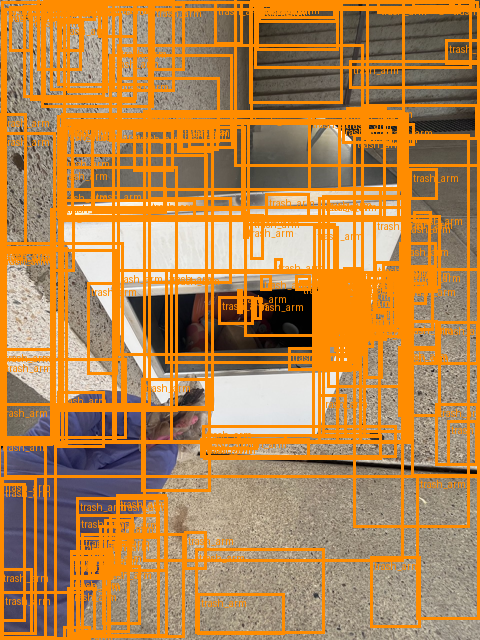

In [67]:
# Get target image and boxes (half them for display purposes in the notebook)
image_to_plot = half_image(random_sample["image"])
boxes_to_plot = half_boxes(random_sample_outputs_post_processed[0]["boxes"])

# Collect the boxes, scores and labels
random_sample_label_names = []
for result in random_sample_outputs_post_processed:
     for score, label_id, box in zip(result["scores"], 
                                     result["labels"], 
                                     result["boxes"]):
         score, label = score.item(), label_id.item()
         box = [round(i, 2) for i in box.tolist()]
         # Optionally print out each prediction 
         # print(f"[INFO] {model.config.id2label[label]}: {score:.2f} {box}")

         random_sample_label_names.append(model.config.id2label[label])

# Get the list of colours to plot
random_sample_colours = [colour_palette[label_name] for label_name in random_sample_label_names]
# print(f"Label names: {random_sample_label_names}")
# print(f"Colour codes: {random_sample_colours}")

# Create the output image with plotted boxes
output_image_with_boxes = to_pil_image(
    pic=draw_bounding_boxes(
        image=pil_to_tensor(pic=image_to_plot),
        boxes=boxes_to_plot,
        labels=random_sample_label_names,
        colors=random_sample_colours,
        width=3,
        # label_colors=random_sample_colours
    )
)
output_image_with_boxes

## Reproducing the **postprocessed box scores** by hand

In [68]:
random_sample_outputs_post_processed[0].keys()

random_sample_outputs_post_processed[0]['scores'], random_sample_outputs_post_processed[0]['scores'].shape

(tensor([0.5017, 0.4619, 0.4580, 0.4530, 0.4458, 0.4417, 0.4414, 0.4398, 0.4384,
         0.4360, 0.4353, 0.4311, 0.4306, 0.4241, 0.4233, 0.4219, 0.4217, 0.4215,
         0.4190, 0.4181, 0.4175, 0.4169, 0.4151, 0.4130, 0.4121, 0.4117, 0.4107,
         0.4106, 0.4099, 0.4087, 0.4062, 0.4060, 0.4019, 0.4004, 0.4002, 0.3992,
         0.3980, 0.3962, 0.3960, 0.3957, 0.3952, 0.3931, 0.3917, 0.3914, 0.3907,
         0.3901, 0.3892, 0.3891, 0.3889, 0.3888, 0.3875, 0.3870, 0.3866, 0.3862,
         0.3858, 0.3852, 0.3840, 0.3833, 0.3831, 0.3825, 0.3808, 0.3768, 0.3764,
         0.3755, 0.3754, 0.3749, 0.3746, 0.3744, 0.3742, 0.3715, 0.3698, 0.3687,
         0.3680, 0.3678, 0.3675, 0.3663, 0.3657, 0.3657, 0.3655, 0.3652, 0.3650,
         0.3649, 0.3638, 0.3628, 0.3621, 0.3619, 0.3615, 0.3611, 0.3611, 0.3605,
         0.3595, 0.3594, 0.3569, 0.3568, 0.3539, 0.3535, 0.3528, 0.3526, 0.3521,
         0.3517, 0.3512, 0.3499, 0.3494, 0.3485, 0.3482, 0.3480, 0.3471, 0.3469,
         0.3468, 0.3462, 0.3

In [69]:
# Get the output scores from our post processed single output
output_scores = random_sample_outputs_post_processed[0]["scores"]
print(len(output_scores), output_scores)

200 tensor([0.5017, 0.4619, 0.4580, 0.4530, 0.4458, 0.4417, 0.4414, 0.4398, 0.4384,
        0.4360, 0.4353, 0.4311, 0.4306, 0.4241, 0.4233, 0.4219, 0.4217, 0.4215,
        0.4190, 0.4181, 0.4175, 0.4169, 0.4151, 0.4130, 0.4121, 0.4117, 0.4107,
        0.4106, 0.4099, 0.4087, 0.4062, 0.4060, 0.4019, 0.4004, 0.4002, 0.3992,
        0.3980, 0.3962, 0.3960, 0.3957, 0.3952, 0.3931, 0.3917, 0.3914, 0.3907,
        0.3901, 0.3892, 0.3891, 0.3889, 0.3888, 0.3875, 0.3870, 0.3866, 0.3862,
        0.3858, 0.3852, 0.3840, 0.3833, 0.3831, 0.3825, 0.3808, 0.3768, 0.3764,
        0.3755, 0.3754, 0.3749, 0.3746, 0.3744, 0.3742, 0.3715, 0.3698, 0.3687,
        0.3680, 0.3678, 0.3675, 0.3663, 0.3657, 0.3657, 0.3655, 0.3652, 0.3650,
        0.3649, 0.3638, 0.3628, 0.3621, 0.3619, 0.3615, 0.3611, 0.3611, 0.3605,
        0.3595, 0.3594, 0.3569, 0.3568, 0.3539, 0.3535, 0.3528, 0.3526, 0.3521,
        0.3517, 0.3512, 0.3499, 0.3494, 0.3485, 0.3482, 0.3480, 0.3471, 0.3469,
        0.3468, 0.3462, 0.3455, 0.34

In [70]:
print(f"[INFO] Original input logits shape: {random_sample_outputs.logits.shape}, which means 300 independent predictions, where each prediction contains scores for the 7 possible categories.\n") 
print('300 is a selected model hyperparameter which in analytical terms tells at most how many objects should a model try to find. \n')

# 1. Perform sigmoid on the logits to get prediction probabilities 
output_scores_manual = random_sample_outputs.logits.sigmoid().flatten(start_dim=1)
print(f"[INFO] Manual output scores shape after flattening: {output_scores_manual.shape}")
# print(f"[INFO] First 10 scores (these will be in random order):\n{output_scores_manual[0][:10].detach().cpu()}\n")

# 2. Get the top 100 scores (we can get any top amount but 100 will do for now) 
output_scores_manual_top_100, output_scores_manual_top_100_indices = torch.topk(input=output_scores_manual,
                                                                                k=100,
                                                                                dim=-1)
print(f"[INFO] Top 100 scores shape: {output_scores_manual_top_100.shape}")
print(f"[INFO] First top 100 score:\n{output_scores_manual_top_100[0][0].item():.4f}\n")

# 3. Find the values above the threshold and create a mask
output_scores_manual_mask = output_scores_manual_top_100 > THRESHOLD # Include values from the top 100 which are above the Threshold

# 4. Sort the top 100 scores which are above the threshold and sort them in descending order and get the indices
output_scores_manual_filtered, output_scores_manual_filtered_indices = torch.sort(input=output_scores_manual_top_100[output_scores_manual_mask], 
                                                                                  descending=True)

print(f"[INFO] Filtered scores shape: {output_scores_manual_filtered.shape}")
print(f"[INFO] First filtered scores:\n{output_scores_manual_filtered[0].detach().cpu():.4f}")

[INFO] Original input logits shape: torch.Size([1, 300, 7]), which means 300 independent predictions, where each prediction contains scores for the 7 possible categories.

300 is a selected model hyperparameter which in analytical terms tells at most how many objects should a model try to find. 

[INFO] Manual output scores shape after flattening: torch.Size([1, 2100])
[INFO] Top 100 scores shape: torch.Size([1, 100])
[INFO] First top 100 score:
0.5017

[INFO] Filtered scores shape: torch.Size([100])
[INFO] First filtered scores:
0.5017


In [71]:
# Compare the original output scores to our own manual version
torch.isclose(input=output_scores[:len(output_scores_manual_filtered)], 
              other=output_scores_manual_filtered, 
              atol=1e-2)

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])

## Reproducing the **postprocessed box labels** by hand

In [72]:
# Get the model's predicted labels 
output_labels = random_sample_outputs_post_processed[0]["labels"]
print(f"[INFO] Output labels shape: {len(output_labels)}")
print(f"[INFO] Output labels:\n{output_labels}")

[INFO] Output labels shape: 200
[INFO] Output labels:
tensor([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6])


In [73]:
# 1. Get the number of classes
num_classes = random_sample_outputs.logits.shape[2] # [1, 300, 7]
print(f"[INFO] Found total number of classes: {num_classes}")

# 2. Modulo the output_scores_manual_top_100_indices by the number of classes to get the predicted class (this is because we flattened our outputs above with .flatten(1))
output_labels_manual = output_scores_manual_top_100_indices % num_classes # Find out the corresponding labels of the top 100 output_scores - i.e the labels of the 1op 100 scores

# 3. Find the top labels which pass our score threshold
output_labels_manual_filtered = output_labels_manual[0][output_scores_manual_filtered_indices]

output_labels.shape, output_labels_manual_filtered.shape


[INFO] Found total number of classes: 7


(torch.Size([200]), torch.Size([100]))

In [74]:
# Make sure these labels are equivalent to the postprocessed labels.
output_labels[:len(output_labels_manual_filtered)] == output_labels_manual_filtered

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])

## Reproducing our postprocessed box coordinates by hand

In [75]:
# These are in absolute XYXY (x_top_left, y_top_left, x_bottom_right, y_bottom_right) format
output_boxes = random_sample_outputs_post_processed[0]["boxes"]
print(f"[INFO] Output boxes shape: {output_boxes.shape}")
print(f"[INFO] Output boxes (absolute XYXY format), first 10:\n{output_boxes[:10]}")

[INFO] Output boxes shape: torch.Size([200, 4])
[INFO] Output boxes (absolute XYXY format), first 10:
tensor([[ 833.2727,  949.9410,  959.8333, 1239.6056],
        [ 698.6367,  120.0690,  959.2045,  177.8421],
        [ 823.6995,  536.9623,  959.9943,  952.4492],
        [ 499.2373,    9.5796,  684.3002,  207.1607],
        [ 208.6647, 1038.4407,  262.8417, 1140.6891],
        [ 672.0793,  653.0602,  695.3784,  715.7731],
        [ 877.7872,  642.4407,  956.6763,  728.5133],
        [ 233.3749,  989.6213,  332.6629, 1143.1658],
        [ 732.9806,  560.9716,  784.8838,  662.2034],
        [ 685.0710,  625.5776,  700.3372,  659.7087]],
       grad_fn=<SliceBackward0>)


In [76]:
# Get model output raw boxes
# These are in format: normalized CXCYWH (center_x, center_y, width, height) format
output_boxes_manual_cxcywh = random_sample_outputs.pred_boxes[0]
print(f"[INFO] Output boxes manual shape: {output_boxes_manual_cxcywh.shape}")
print(f"[INFO] Output boxes manual (normalized CXCYWH format), first 10:\n{output_boxes_manual_cxcywh[:10]}")

[INFO] Output boxes manual shape: torch.Size([300, 4])
[INFO] Output boxes manual (normalized CXCYWH format), first 10:
tensor([[0.5221, 0.5348, 0.1337, 0.1498],
        [0.4286, 0.5847, 0.8409, 0.8155],
        [0.5377, 0.4821, 0.0133, 0.0338],
        [0.5433, 0.6806, 0.2457, 0.0189],
        [0.5663, 0.2636, 0.1235, 0.0317],
        [0.7174, 0.4917, 0.0530, 0.0738],
        [0.1258, 0.6382, 0.0264, 0.0222],
        [0.0398, 0.8690, 0.0737, 0.2456],
        [0.5442, 0.6841, 0.2294, 0.0151],
        [0.1981, 0.5980, 0.3906, 0.7823]], grad_fn=<SliceBackward0>)


In [77]:
# Get model output raw boxes
# These are in format: normalized CXCYWH (center_x, center_y, width, height) format
output_boxes_manual_cxcywh = random_sample_outputs.pred_boxes[0]
print(f"[INFO] Output boxes manual shape: {output_boxes_manual_cxcywh.shape}")
print(f"[INFO] Output boxes manual (normalized CXCYWH format), first 10:\n{output_boxes_manual_cxcywh[:10]}")

[INFO] Output boxes manual shape: torch.Size([300, 4])
[INFO] Output boxes manual (normalized CXCYWH format), first 10:
tensor([[0.5221, 0.5348, 0.1337, 0.1498],
        [0.4286, 0.5847, 0.8409, 0.8155],
        [0.5377, 0.4821, 0.0133, 0.0338],
        [0.5433, 0.6806, 0.2457, 0.0189],
        [0.5663, 0.2636, 0.1235, 0.0317],
        [0.7174, 0.4917, 0.0530, 0.0738],
        [0.1258, 0.6382, 0.0264, 0.0222],
        [0.0398, 0.8690, 0.0737, 0.2456],
        [0.5442, 0.6841, 0.2294, 0.0151],
        [0.1981, 0.5980, 0.3906, 0.7823]], grad_fn=<SliceBackward0>)


In [78]:
# 1. Normalize the indices by dividing by the number of classes (this is because we flattened our logits tensor in a previous step) 
output_scores_manual_top_100_indicies_normalized = output_scores_manual_top_100_indices[0] // num_classes
output_scores_manual_top_100_indicies_normalized

tensor([218, 299, 290, 209, 143,  23, 284, 139,  80, 156, 187, 248, 116, 181,
        103,  43, 177,  45, 155,  77, 188, 172, 104,  35,  46, 168, 259,  34,
        128,  90, 144, 231,  71,   5, 183,  13,  75, 282, 167,  66, 163, 197,
        131, 138, 112, 122,  84, 102, 159,  40, 141,  14, 186, 194, 267, 223,
        202, 191, 127,  59,  85, 270, 269, 123, 201,  78, 280, 242, 296,  21,
        105,  42,  94, 254, 260, 101, 146, 212, 207, 257, 162,  63, 110, 115,
         52, 203, 277,  68, 230, 229, 148,  67, 134, 200,  99,  39, 185,  11,
         82, 227])

In [79]:
# 2. Filter boxes for top 100 above the target threshold
output_boxes_manual_above_threshold_cxcywh = output_boxes_manual_cxcywh[output_scores_manual_top_100_indicies_normalized]

print(f"[INFO] Output boxes manual above threshold shape: {output_boxes_manual_above_threshold_cxcywh.shape}")
print(f"[INFO] Output boxes manual above threshold (normalized CXCYWH format), \
showing first 10:\n{output_boxes_manual_above_threshold_cxcywh[:10, :]}")

[INFO] Output boxes manual above threshold shape: torch.Size([100, 4])
[INFO] Output boxes manual above threshold (normalized CXCYWH format), showing first 10:
tensor([[0.9339, 0.8553, 0.1318, 0.2263],
        [0.8635, 0.1164, 0.2714, 0.0451],
        [0.9290, 0.5818, 0.1420, 0.3246],
        [0.6164, 0.0847, 0.1928, 0.1544],
        [0.2456, 0.8512, 0.0564, 0.0799],
        [0.7122, 0.5347, 0.0243, 0.0490],
        [0.9554, 0.5355, 0.0822, 0.0672],
        [0.2948, 0.8331, 0.1034, 0.1200],
        [0.7906, 0.4778, 0.0541, 0.0791],
        [0.7216, 0.5021, 0.0159, 0.0267]], grad_fn=<SliceBackward0>)


In [80]:
from torchvision.ops import box_convert

# 3. Convert the model's predicted boxes from CXCYWH to XYXY format
output_boxes_manual_above_threshold_xyxy = box_convert(boxes=output_boxes_manual_above_threshold_cxcywh,
                                                       in_fmt="cxcywh",
                                                       out_fmt="xyxy")
print(f"[INFO] Output boxes manual above threshold (absolute XYXY format):\n{output_boxes_manual_above_threshold_xyxy[:10]}")

[INFO] Output boxes manual above threshold (absolute XYXY format):
tensor([[0.8680, 0.7421, 0.9998, 0.9684],
        [0.7277, 0.0938, 0.9992, 0.1389],
        [0.8580, 0.4195, 1.0000, 0.7441],
        [0.5200, 0.0075, 0.7128, 0.1618],
        [0.2174, 0.8113, 0.2738, 0.8912],
        [0.7001, 0.5102, 0.7244, 0.5592],
        [0.9144, 0.5019, 0.9965, 0.5692],
        [0.2431, 0.7731, 0.3465, 0.8931],
        [0.7635, 0.4383, 0.8176, 0.5173],
        [0.7136, 0.4887, 0.7295, 0.5154]], grad_fn=<SliceBackward0>)


In [81]:
# 4. Get the original input image size (required for box conversion)
random_sample_image_original_size = random_sample_preprocessed["labels"][0]["orig_size"]
print(f"[INFO] Image original size: {random_sample_image_original_size} (height, width)")

[INFO] Image original size: tensor([1280,  960]) (height, width)


In [82]:
# 5. Convert normalized box coordinates to absolute pixel values

# Get image original height and width
original_height, original_width = random_sample_image_original_size

# Create an XYXY tensor to multiply by
original_dimensions = torch.tensor([original_width,   # x1
                                    original_height,  # y1 
                                    original_width,   # x2
                                    original_height]) # y2

# Convert the boxes to absolute pixel values
output_boxes_manual_above_threshold_xyxy_absolute = output_boxes_manual_above_threshold_xyxy * original_dimensions
output_boxes_manual_above_threshold_xyxy_absolute[:10]

tensor([[ 833.2727,  949.9410,  959.8333, 1239.6056],
        [ 698.6367,  120.0690,  959.2045,  177.8421],
        [ 823.6995,  536.9623,  959.9943,  952.4492],
        [ 499.2373,    9.5796,  684.3002,  207.1607],
        [ 208.6647, 1038.4407,  262.8417, 1140.6891],
        [ 672.0793,  653.0602,  695.3784,  715.7731],
        [ 877.7872,  642.4407,  956.6763,  728.5133],
        [ 233.3749,  989.6213,  332.6629, 1143.1658],
        [ 732.9806,  560.9716,  784.8838,  662.2034],
        [ 685.0710,  625.5776,  700.3372,  659.7087]],
       grad_fn=<SliceBackward0>)

In [83]:
# 6. Order boxes in same order as labels and scores (descending based on score)
output_boxes_manual_sorted = output_boxes_manual_above_threshold_xyxy_absolute[output_scores_manual_filtered_indices]
output_boxes_manual_sorted[:10]

tensor([[ 833.2727,  949.9410,  959.8333, 1239.6056],
        [ 698.6367,  120.0690,  959.2045,  177.8421],
        [ 823.6995,  536.9623,  959.9943,  952.4492],
        [ 499.2373,    9.5796,  684.3002,  207.1607],
        [ 208.6647, 1038.4407,  262.8417, 1140.6891],
        [ 672.0793,  653.0602,  695.3784,  715.7731],
        [ 877.7872,  642.4407,  956.6763,  728.5133],
        [ 233.3749,  989.6213,  332.6629, 1143.1658],
        [ 732.9806,  560.9716,  784.8838,  662.2034],
        [ 685.0710,  625.5776,  700.3372,  659.7087]],
       grad_fn=<SliceBackward0>)

In [84]:
# 7. Check for equivalence between original postprocessed boxes and our manually processed boxes
torch.all(input=output_boxes[:100] == output_boxes_manual_sorted)

tensor(True)

## Plotting the model’s first box predictions on an image

[INFO] Labels with scores: ['Pred: trash_arm (0.5017)', 'Pred: trash_arm (0.4619)', 'Pred: trash_arm (0.458)']...


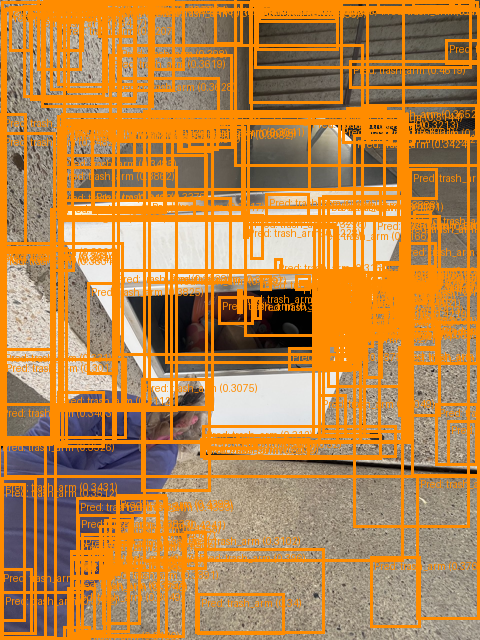

In [85]:
# 1. Extract scores, labels and boxes
random_sample_pred_scores = random_sample_outputs_post_processed[0]["scores"]
random_sample_pred_labels = random_sample_outputs_post_processed[0]["labels"]
random_sample_pred_boxes = half_boxes(random_sample_outputs_post_processed[0]["boxes"])

# 2. Create a list of labels and colours to plot on the image/boxes
random_sample_pred_labels_to_plot = [f"Pred: {id2label[label_pred.item()]} ({round(score_pred.item(), 4)})" 
                  for label_pred, score_pred in zip(random_sample_pred_labels, random_sample_pred_scores)]
random_sample_pred_colours = [colour_palette[id2label[label_pred.item()]] for label_pred in random_sample_pred_labels]

print(f"[INFO] Labels with scores: {random_sample_pred_labels_to_plot[:3]}...")

# 3. Plot the random sample image with randomly predicted boxes 
# (these will be very poor since the model is not trained on our data yet)
to_pil_image(
    pic=draw_bounding_boxes(
        image=pil_to_tensor(pic=half_image(random_sample["image"])),
        boxes=random_sample_pred_boxes, # boxes are in XYXY format, which is required for draw_bounding_boxes
        labels=random_sample_pred_labels_to_plot,
        colors=random_sample_pred_colours,
        width=3
    )
)

# Section 9 : Preparing data at scale

Splitting the data into training and test sets

In [86]:
# Original dataset (only a "train" split)
dataset = load_dataset(path="mrdbourke/trashify_manual_labelled_images")
original_dataset_length = len(dataset["train"])
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 1128
    })
})

In [87]:
# Note: Be careful of running this cell multiple times, if you do, the dataset size will get smaller. 
# If this happens, just reload the whole `dataset` as above.

# 1. Split the data into "train" and "test" splits
dataset_split = dataset["train"].train_test_split(test_size=0.3, seed=42) # split the dataset into 70/30 train/test

# 2. Split the test split into "test" and "validation" splits
dataset_test_val_split = dataset_split["test"].train_test_split(test_size=0.66, seed=42) # split the test set into 40/60 validation/test

# Create "train" split from 1.
dataset["train"] = dataset_split["train"]

# Create a "validation" and "test" split from 2.
dataset["validation"] = dataset_test_val_split["train"]
dataset["test"] = dataset_test_val_split["test"]

# Ensure splits lengths add to equal original dataset length (otherwise there's a mistmatch somewhere)
assert original_dataset_length == len(dataset["train"]) + len(dataset["validation"]) + len(dataset["test"]), "Total dataset split lengths don't equal original dataset length, is there a mismatch? Perhaps try reloading the original dataset and re-running this cell."

# View the dataset (now with splits)
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 789
    })
    validation: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 115
    })
    test: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 224
    })
})

Writing a function for preprocessing multiple samples at a time

In [88]:
# Get one sample from the training dataset 
one_sample = dataset['train'][42]
one_sample

{'image': <PIL.Image.Image image mode=RGB size=960x1280>,
 'image_id': 663,
 'annotations': {'file_name': ['1d2ea64a-0296-403d-93cd-31e3f116c995.jpeg',
   '1d2ea64a-0296-403d-93cd-31e3f116c995.jpeg'],
  'image_id': [663, 663],
  'category_id': [1, 5],
  'bbox': [[413.29998779296875,
    529.7000122070312,
    343.6000061035156,
    687.0999755859375],
   [435.8999938964844, 463.0, 77.19999694824219, 99.9000015258789]],
  'iscrowd': [0, 0],
  'area': [236087.5625, 7712.27978515625]},
 'label_source': 'manual_prodigy_label',
 'image_source': 'manual_taken_photo'}

In [89]:
# Get three samples from the training set
group_of_samples = dataset["train"][0:3]
group_of_samples

{'image': [<PIL.Image.Image image mode=RGB size=960x1280>,
  <PIL.Image.Image image mode=RGB size=960x1280>,
  <PIL.Image.Image image mode=RGB size=960x1280>],
 'image_id': [69, 1027, 1092],
 'annotations': [{'file_name': ['c56fee61-959c-44b8-ada2-807d2ff45f90.jpeg',
    'c56fee61-959c-44b8-ada2-807d2ff45f90.jpeg',
    'c56fee61-959c-44b8-ada2-807d2ff45f90.jpeg',
    'c56fee61-959c-44b8-ada2-807d2ff45f90.jpeg',
    'c56fee61-959c-44b8-ada2-807d2ff45f90.jpeg',
    'c56fee61-959c-44b8-ada2-807d2ff45f90.jpeg',
    'c56fee61-959c-44b8-ada2-807d2ff45f90.jpeg',
    'c56fee61-959c-44b8-ada2-807d2ff45f90.jpeg'],
   'image_id': [69, 69, 69, 69, 69, 69, 69, 69],
   'category_id': [5, 0, 1, 4, 4, 4, 4, 4],
   'bbox': [[360.20001220703125, 528.5, 177.1999969482422, 261.79998779296875],
    [298.29998779296875,
     495.1000061035156,
     381.1000061035156,
     505.70001220703125],
    [81.5999984741211,
     592.0999755859375,
     358.79998779296875,
     316.29998779296875],
    [1.29999995231

Okay, now we get a list of image objects as well as a list of annotation dictionaries and more in the format:

```python
{
    "image": [<PIL.Image.Image>, <PIL.Image.Image>, ...],
    "image_id": [int, int, ...],
    "annotations": [
        {
            "file_name": [str, str, ...],
            "image_id": [int, int, ...],
            "category_id": [int, int, ...],
            "bbox": [[float, float, float, float], ...],
            "iscrowd": [int, int, ...],
            "area": [float, float, ...]
        },
        {...},
        {...}
    ],
    "label_source": [str, str, ...],
    "image_source": [str, str, ...]
}

```

In [90]:
# 1. Take in a list of examples, image processor and optional transforms
def preprocess_batch(examples, 
                     image_processor,
                     transforms=None, # Note: Could optionally add transforms (e.g. data augmentation) here 
                     ):
    """
    Preprocesses a batch of image data with annotations for object detection models.

    This function takes a batch of examples in a custom dataset format, extracts images and
    their corresponding annotations, and converts them into a format suitable for model training
    or inference using the provided image processor.

    Args:
        examples (dict): A dictionary containing the batch data with the following structure:
            - "image" (List[PIL.Image.Image]): List of PIL Image objects
            - "image_id" (List[int]): List of unique image identifiers
            - "annotations" (List[dict]): List of annotation dictionaries, where each contains:
                - "file_name" (List[str]): List of image filenames
                - "image_id" (List[int]): List of image identifiers
                - "category_id" (List[int]): List of object category IDs
                - "bbox" (List[List[float]]): List of bounding boxes as [x, y, width, height]
                - "iscrowd" (List[int]): List of crowd indicators (0 or 1)
                - "area" (List[float]): List of object areas
            - "label_source" (List[str]): List of label sources
            - "image_source" (List[str]): List of image sources

        image_processor: An image processor object to preprocess images for model input.
            For example, can be `transformers.RTDetrDetrImageProcessor`.

        transforms (optional): Image and annotations transforms for data augmentation.
            Defaults to None.

    Returns:
        dict: Preprocessed batch with images and annotations converted to tensors
            in the format required for a `transformers.RTDetrV2ForObjectDetection` model.

    Note:
        The `format_image_annotations_as_coco` function converts the input annotation format to COCO
        format before applying the image_processor. This is required as the image_processor is designed
        to handle COCO format annotations. 
    """
    # 2. Create empty lists to store images and annotations
    images = []
    coco_annotations = [] 

    # 3. Extract the image, image_id and annotations from the examples
    for image, image_id, annotations_dict in zip(examples["image"], 
                                                 examples["image_id"], 
                                                 examples["annotations"]):

        # 4. Create lists of annotation attributes
        bbox_list = annotations_dict["bbox"]
        category_list = annotations_dict["category_id"]
        area_list = annotations_dict["area"]

        ###
        # 5. Note: Could optionally apply a transform/augmentation here.
        # See PyTorch docs for more: https://docs.pytorch.org/vision/main/auto_examples/transforms/plot_transforms_e2e.html
        if transforms:
            # Perform transform on image/boxes
            pass
        ###

        # 6. Format the annotations into COCO format
        coco_format_annotations = format_image_annotations_as_coco(image_id=image_id,
                                                                   categories=category_list,
                                                                   areas=area_list,
                                                                   bboxes=bbox_list)
        
        # 7. Add images/annotations to their respective lists
        images.append(image) # Note: may need to open image if it is an image path rather than PIL.Image
        coco_annotations.append(coco_format_annotations)

    
    # 8. Apply the image processor to lists of images and annotations
    preprocessed_batch = image_processor.preprocess(images=images,
                                                    annotations=coco_annotations,
                                                    return_tensors="pt")

    # 9. Return the preprocessed batch
    return preprocessed_batch

In [91]:
preprocessed_samples = preprocess_batch(examples=group_of_samples,
                                        image_processor=image_processor)

preprocessed_samples.keys()

KeysView({'pixel_mask': tensor([[[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]],

        [[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]],

        [[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]]), 'pixel_values': tensor([[[[0.1216, 0.1216, 0.1176,  ..., 0.1961, 0.1961, 0.1922],
          [0.1216, 0.1216, 0.1216,  ..., 0.2706, 0.2745, 0.2745],
          [0.1176, 0.1216, 0.1216,  ..., 0.2980, 0.2941, 0.2980],
          ...,
          [0.1882, 0.1569, 0.3490,  ..., 0.3569, 0.4196, 0.3922],
  

In [92]:
# Check the shape of our preprocessed samples
print(f"[INFO] Shape of preprocessed samples: {preprocessed_samples['pixel_values'].shape} -> [batch_size, colour_channels, height, width]")

[INFO] Shape of preprocessed samples: torch.Size([3, 3, 640, 480]) -> [batch_size, colour_channels, height, width]


Applying our preprocessing function to each data split

In [93]:
# Create a partial function for preprocessing
from functools import partial

# Note: Could create separate preprocess functions with different inputs depending on the split 
# (e.g. use data augmentation on training but not on validation/test)
preprocess_batch_partial = partial(preprocess_batch,
                                   image_processor=image_processor,
                                   transforms=None) # could use transforms here if wanted

# Inspect the preprocess_batch_partial function
preprocess_batch_partial

functools.partial(<function preprocess_batch at 0x76dc94faa980>, image_processor=RTDetrImageProcessorFast {
  "data_format": "channels_first",
  "do_convert_annotations": true,
  "do_normalize": false,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "RTDetrImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "return_segmentation_masks": true,
  "size": {
    "longest_edge": 640,
    "shortest_edge": 640
  }
}
, transforms=None)

In [94]:
# Create a copy of the original dataset 
# (we don't need to do this, this is just so we can inspect the original dataset later on)
processed_dataset = dataset.copy()

# Apply the preprocessing function to the datasets (the preprocessing will happen on the fly, e.g. when the dataset is called rather than in-place)
processed_dataset["train"] = dataset["train"].with_transform(transform=preprocess_batch_partial)
processed_dataset["validation"] = dataset["validation"].with_transform(transform=preprocess_batch_partial)
processed_dataset["test"] = dataset["test"].with_transform(transform=preprocess_batch_partial)

Now when we get (via ```__getitem__```) one of our samples from a processed_dataset split, it will be preprocessed on the fly.



In [95]:
# Get an item from the dataset (in will be preprocessed as we get it)
processed_dataset["train"][42]

{'pixel_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]),
 'pixel_values': tensor([[[0.0824, 0.2275, 0.2471,  ..., 0.3255, 0.3059, 0.3804],
          [0.2588, 0.1608, 0.2706,  ..., 0.4000, 0.4588, 0.4667],
          [0.2706, 0.2588, 0.2549,  ..., 0.7059, 0.5686, 0.4431],
          ...,
          [0.4941, 0.3137, 0.2235,  ..., 0.2745, 0.2314, 0.1647],
          [0.4824, 0.5490, 0.2392,  ..., 0.1725, 0.1451, 0.2157],
          [0.3176, 0.5294, 0.3137,  ..., 0.2039, 0.1059, 0.1490]],
 
         [[0.0941, 0.2392, 0.2549,  ..., 0.3176, 0.2941, 0.3765],
          [0.2706, 0.1686, 0.2784,  ..., 0.3922, 0.4471, 0.4588],
          [0.2784, 0.2667, 0.2588,  ..., 0.6980, 0.5569, 0.4353],
          ...,
          [0.4667, 0.2824, 0.1882,  ..., 0.2902, 0.2549, 0.2000],
          [0.4510, 0.5098, 0.2000,  ..., 0.1922, 0.

And the same happens when we get multiple (a batch) samples

In [96]:
# Now when we call one or more of our samples, the preprocessing will take place
batch_size_to_get = 32
print(f"[INFO] Shape of preprocessed images: {processed_dataset['train'][:batch_size_to_get]['pixel_values'].shape} -> [batch_size, colour_channels, height, width]")

[INFO] Shape of preprocessed images: torch.Size([32, 3, 640, 480]) -> [batch_size, colour_channels, height, width]


NOTE about Batch Size: 

Generally use the batch size which uses the maximum amount of GPU memory you have.

For example, if you have 16GB of GPU memory and a batch size of 32 only uses 8GB of that memory, you should try doubling the batch size to 64.

In [97]:
from typing import List, Dict, Any

def data_collate_function(preprocessed_batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    """Stacks together groups of preprocessed samples into batches for our model.

    Args:
        preprocessed_batch: A list of dictionaries where each dictionary represents a preprocessed sample.

    Returns:
        collated_data: A dictionary containing the batched data ready in the format our model
            is expecting. The dictionary has the following keys: 
                - "pixel_values": A stacked tensor of preprocessed pixel values.
                - "labels": A list of label dictionaries.
                - "pixel_mask": (Optional) A stacked tensor of pixel masks (this will be present 
                    only if the input contains a "pixel_mask" key.
    """
    # Create an empty dictionary (our model wants a dictionary input) 
    collated_data = {} 

    # Stack together a collection of pixel_values tensors
    collated_data["pixel_values"] = torch.stack([sample["pixel_values"] for sample in preprocessed_batch])

    # Get the labels (these are dictionaries so no need to use torch.stack)
    collated_data["labels"] = [sample["labels"] for sample in preprocessed_batch]

    # If there is a pixel_mask key, return the pixel_mask's as well
    if "pixel_mask" in preprocessed_batch[0]:
        collated_data["pixel_mask"] = torch.stack([sample["pixel_mask"] for sample in preprocessed_batch])

    return collated_data

In [98]:
%%time

# Try data_collate_function 
example_collated_data_batch = data_collate_function(processed_dataset["train"].select(range(8))) # Works fine till 8. Cracks up 16 onwards
example_collated_data_batch.keys()

CPU times: user 3.1 s, sys: 13.1 ms, total: 3.12 s
Wall time: 299 ms


dict_keys(['pixel_values', 'labels', 'pixel_mask'])

In [99]:
# Check shapes of batched preprocessed samples
print(f"[INFO] Batch of pixel value shapes: {example_collated_data_batch['pixel_values'].shape}")
print(f"[INFO] Batch of labels: {example_collated_data_batch['labels']}")
if "pixel_mask" in example_collated_data_batch:
    print(f"[INFO] Batch of pixel masks: {example_collated_data_batch['pixel_mask'].shape}")

[INFO] Batch of pixel value shapes: torch.Size([8, 3, 640, 480])
[INFO] Batch of labels: [{'size': tensor([640, 480]), 'image_id': tensor([69]), 'class_labels': tensor([5, 0, 1, 4, 4, 4, 4, 4]), 'boxes': tensor([[0.4675, 0.5152, 0.1846, 0.2045],
        [0.5092, 0.5843, 0.3970, 0.3951],
        [0.2719, 0.5861, 0.3738, 0.2471],
        [0.1023, 0.6896, 0.2019, 0.1655],
        [0.3902, 0.0924, 0.1530, 0.0898],
        [0.5345, 0.0871, 0.0252, 0.0556],
        [0.6370, 0.0877, 0.1357, 0.0899],
        [0.9383, 0.0634, 0.0789, 0.0627]]), 'area': tensor([11597.7402, 48180.5664, 28372.1094, 10266.5547,  4223.3750,   430.7600,
         3749.3826,  1517.7850]), 'iscrowd': tensor([0, 0, 0, 0, 0, 0, 0, 0]), 'orig_size': tensor([1280,  960])}, {'size': tensor([640, 480]), 'image_id': tensor([1027]), 'class_labels': tensor([5, 4, 1, 0, 0]), 'boxes': tensor([[0.4669, 0.5782, 0.1456, 0.1290],
        [0.5031, 0.6013, 0.0410, 0.0237],
        [0.5269, 0.6380, 0.1138, 0.1280],
        [0.3863, 0.504

Passing pixel values through the model

In [100]:
%%time 

# Try pass a batch through our model (note: this will be relatively slow if our model is on the CPU)
model = create_model()

# example_batch_outputs = model(example_collated_data_batch["pixel_values"])
example_batch_outputs = model(example_collated_data_batch["pixel_values"])
# example_batch_outputs # uncomment for full output
example_batch_outputs.keys()

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

RTDetrV2ForObjectDetection LOAD REPORT from: PekingU/rtdetr_v2_r50vd
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([7, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([8, 256])
model.enc_sco

CPU times: user 36.2 s, sys: 9.31 s, total: 45.5 s
Wall time: 3.54 s


odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'intermediate_hidden_states', 'intermediate_logits', 'intermediate_reference_points', 'encoder_last_hidden_state', 'init_reference_points', 'enc_topk_logits', 'enc_topk_bboxes', 'enc_outputs_class', 'enc_outputs_coord_logits'])

In [101]:
# We get 300 predictions per image in our batch, each with a logit value for each of the classes in our dataset 
example_batch_outputs.logits.shape

torch.Size([8, 300, 7])

# Section 10 : Setting up Training Arguments and a Trainer instance to train the model

In [102]:
# 1. Create a model instance 
model = create_model()

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

RTDetrV2ForObjectDetection LOAD REPORT from: PekingU/rtdetr_v2_r50vd
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([7, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([8, 256])
model.enc_sco

In [103]:
from pathlib import Path

# 2. Make a models directory for saving models
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

## Setting up our TrainingArguments

In [104]:
# 3. Create an instance of TrainingArguments to pass to Trainer
from transformers import TrainingArguments

# Hardware dependent hyperparameters
# Set the batch size according to the memory you have available on your GPU
# e.g. on my NVIDIA RTX 4090 with 24GB of VRAM, I can use a batch size of 32 
# without running out of memory
BATCH_SIZE = 8
DATALOADER_NUM_WORKERS = 4 # note: if you're on Google Colab, you may have to lower this to os.cpu_count() or to 0 

# Set number of epochs to how many laps you'd like to do over the data
NUM_EPOCHS = 10

# Setup hyperameters for training from the DETR paper(s)
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 0.1 
WARMUP_RATIO = 0.05 # learning rate warmup from 0 to learning_rate as a ratio of total steps (e.g. 0.05 = 5% of total steps)

# Create directory to save models to 
OUTPUT_DIR = Path(models_dir, "rt_detrv2_finetuned_trashify_box_detector_v1")
print(f"[INFO] Saving model to: {OUTPUT_DIR}")

# Create TrainingArguments to pass to Trainer
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=MAX_GRAD_NORM,
    num_train_epochs=NUM_EPOCHS,
    lr_scheduler_type="linear",
    warmup_ratio=WARMUP_RATIO, 
    # warmup_steps=2000, # number of warmup steps from 0 to learning_rate (overrides warmup_ratio, found this to be too long for our dataset)
    logging_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    fp16=True, # use mixed precision training
    dataloader_num_workers=DATALOADER_NUM_WORKERS, # note: if you're on Google Colab, you may have to lower this to os.cpu_count() or to 0
    eval_strategy="epoch",
    load_best_model_at_end=True, 
    metric_for_best_model="eval_loss",
    greater_is_better=False, # want to minimize eval_loss (e.g. lower is better)
    report_to="none", # don't save experiments to a third party service
    push_to_hub=False,
    eval_do_concat_batches=False, # this defaults to True but we'll set it to False for our evaluation function
    # save_safetensors=False # turn this off to prevent potential checkpoint issues
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[INFO] Saving model to: models/rt_detrv2_finetuned_trashify_box_detector_v1


## Optional: Setting up an optimizer for multiple learning rates

The (RT-DETRv2: Improved Baseline with Bag-of-Freebies for Real-Time Detection Transformer) paper states that they used a different learning rate value for the backbone, learning_rate=1e-5, as well as the object detection head, learning_rate=1e-4 (see Table 1 for RT-DETRv2-L with the ResNet50 backbone in the RT-DETRv2 paper).

In [ ]:
from transformers import Trainer

# Create lists for different kinds of parameters
backbone_parameters = []
other_parameters = []

# Can loop through model parameters and extract different model sections
for name, param in model.model.named_parameters(): 
    if "backbone" in name:
        # print(f"Backbone parameter: {name}")
        backbone_parameters.append(param)
    else:
        # print(f"Other parameter: {name}")
        other_parameters.append(param)

print(f"[INFO] Number of backbone parameter modules: {len(backbone_parameters)}")
print(f"[INFO] Number of other parameter modules: {len(other_parameters)}")

# Commenting this since a small dataset will not benefit from two different learning rates. Finetuning can be optimally done with one learning rate. Keeping things simple.
# The following might be utilized to pretrain the model on a much larger dataset.

# BACKBONE_LEARNING_RATE = 1e-5
# DETECTION_HEAD_LEARNING_RATE = 1e-4

# print(f"[INFO] Using learning rate for backbone: {BACKBONE_LEARNING_RATE}")
# print(f"[INFO] Using learning rate for other parameters and detection head: {DETECTION_HEAD_LEARNING_RATE}")

# # Setup a custom subclass of Trainer to use different learning rates for different parts of the model
# class CustomTrainer(Trainer): # This is just a class which inherits Trainer and modifies the default optimizer by divdiing it into two parts on the basis of the parameter names as done above.
#     def create_optimizer(self):
#         self.optimizer = torch.optim.AdamW([
#             {"params": backbone_parameters, "lr": BACKBONE_LEARNING_RATE},
#             {"params": other_parameters, "lr": DETECTION_HEAD_LEARNING_RATE}
#         ], weight_decay=0.0001)
#         return self.optimizer

[INFO] Number of backbone parameter modules: 55
[INFO] Number of other parameter modules: 363


## Creating an evaluation function

In [106]:
from torchvision.ops import box_convert

def convert_bbox_cxcywh_to_xyxy_absolute(boxes, 
                                         image_size_target):
    """
    Converts CXCYWH normalized boxes to XYXY absolute boxes.

    The output of our preprocess method puts boxes in CXCYWH format.

    But our evaluation metric torchmetrics.detection.mean_ap.MeanAveragePrecision expects
        boxes in XYXY absolute format.

    Args:
        boxes (torch.Tensor): A tensor of shape (N, 4) where N is the number of boxes and each box is in CXCYWH format.
        image_size_target (tuple): A tuple containing the target image size as (height, width).
    
    Returns:
        torch.Tensor: A tensor of shape (N, 4) where each box is converted to XYXY absolute format.
    """
    # Convert normalized CXCYWH (output of model) -> absolute XYXY format (required for evaluation)
    boxes = box_convert(boxes=boxes, in_fmt="cxcywh", out_fmt="xyxy")

    # Convert normalized box coordinates to absolute pixel values based on the target size 
    image_size_target_height = image_size_target[0]
    image_size_target_width = image_size_target[1]
    boxes = boxes * torch.tensor([image_size_target_width, 
                                  image_size_target_height, 
                                  image_size_target_width, 
                                  image_size_target_height]) # Multiply X coordinates by the width and Y coordinates by the height

    return boxes

In [107]:
# Create an evaluation function to test our model's performance
import numpy as np

from typing import Optional, Mapping

from transformers import EvalPrediction

from torchmetrics.detection.mean_ap import MeanAveragePrecision

# 1. Create a dataclass to hold our model's outputs
@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor

# 2. Create a compute_metrics function which takes in EvalPrediction and other required parameters
@torch.no_grad()
def compute_metrics(
    evaluation_results: EvalPrediction, # these come out of the Trainer.evaluate method, see: https://huggingface.co/docs/transformers/en/internal/trainer_utils#transformers.EvalPrediction 
    image_processor: AutoImageProcessor,
    threshold: float = 0.0,
    id2label: Optional[Mapping[int, str]] = None,
) -> Mapping[str, float]:
    """
    Compute mean average mAP, mAR and their variants for the object detection task.

    Args:
        evaluation_results (EvalPrediction): Predictions and targets from evaluation.
        threshold (float, optional): Threshold to filter predicted boxes by confidence. Defaults to 0.0.
        id2label (Optional[dict], optional): Mapping from class id to class name. Defaults to None.

    Returns:
        Mapping[str, float]: Metrics in a form of dictionary {<metric_name>: <metric_value>}
    """

    # 3. Extract predictions and targets from EvalPrediction
    predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

    # For metric computation we need to provide to MeanAveragePrecision
    #  - 'targets' in a form of list of dictionaries with keys "boxes", "labels"
    #  - 'predictions' in a form of list of dictionaries with keys "boxes", "scores", "labels"

    # 4. Get a list of image sizes, processed targets and processed predictions
    image_sizes = []
    post_processed_targets = []
    post_processed_predictions = []

    ### Target collection ###

    # 5. Collect target attributes in the required format for metric computation
    for batch in targets:
        # Collect ground truth image sizes, we will need them for predictions post processing
        batch_image_sizes = torch.tensor(np.array([x["orig_size"] for x in batch])) # turn into a list of numpy arrays first, then tensors
        image_sizes.append(batch_image_sizes)

        # Collect targets in the required format for metric computation
        # boxes were converted to YOLO format needed for model training
        # here we will convert them to Pascal VOC format (x_min, y_min, x_max, y_max) 
        # or XYXY format. We do this because the boxes out of preprocess() are in 
        # CXCYWH normalized format.
        for image_target in batch:

            # Get boxes and convert from CXCYWH to XYXY
            boxes = torch.tensor(image_target["boxes"])
            boxes = convert_bbox_cxcywh_to_xyxy_absolute(boxes=boxes, 
                                                         image_size_target=image_target["orig_size"])
            
            # Get labels
            labels = torch.tensor(image_target["class_labels"])

            # Append box and label pairs in format requried for MeanAveragePrecision class
            post_processed_targets.append({"boxes": boxes, 
                                           "labels": labels})
    
    ### Prediction collection ###

    # 6. Collect predictions in the required format for metric computation,
    # model produce boxes in YOLO format (CXCYWH), then image_processor.post_process_object_detection to 
    # convert them to Pascal VOC format (XYXY).
    for pred_batch, target_sizes in zip(predictions, image_sizes):

        # pred_batch comes in the form of a tuple: (loss, logits, boxes)
        pred_batch_loss, pred_batch_logits, pred_batch_boxes = pred_batch[0], pred_batch[1], pred_batch[2]

        model_output = ModelOutput(logits=torch.tensor(pred_batch_logits), 
                                   pred_boxes=torch.tensor(pred_batch_boxes))
        
        # Post process the model outputs
        post_processed_output = image_processor.post_process_object_detection(
                                                    outputs=model_output, 
                                                    threshold=threshold, 
                                                    target_sizes=target_sizes) # target sizes required to shape boxes in correct ratio of original image
        
        # Extend post_processed_output in form `[{"boxes": [...], "labels": [...], "scores": [...]}]`
        # We extend because post_process_object_detection returns a list of dictionaries, so rather than append a list to a list we extend the existing list
        post_processed_predictions.extend(post_processed_output)

    # 7. Compute mAP
    max_detection_thresholds = [1, 10, 100] # 1 = mar@1, mar@10, mar@100 (100 = default max total boxes for post processed predictions out of object detection model)
    metric = MeanAveragePrecision(box_format="xyxy", 
                                  class_metrics=True,
                                  max_detection_thresholds=max_detection_thresholds) 
    metric.warn_on_many_detections = False # don't output a warning when large amount of detections come out (the sorting handles this anyway)
    metric.update(post_processed_predictions, 
                  post_processed_targets)
    metrics = metric.compute()
    
    # Optional: print metrics dict for troubleshooting
    # print(metrics)

    # 8. Extract list of per class metrics with separate metric for each class
    classes = metrics.pop("classes")
    map_per_class = metrics.pop("map_per_class")

    # Optional: mAR@N per class (mAR = Mean Average Recall)
    mar_per_class = metrics.pop("mar_100_per_class")
    
    # 9. Prepare metrics per class in the form of a dict with metric names -> values, e.g. {"metric_name": 42.0, ...}
    # for class_id, class_map in zip(classes, map_per_class):
    for class_id, class_map, class_mar in zip(classes, map_per_class, mar_per_class):
        class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
        metrics[f"map_{class_name}"] = class_map

        # Optional: mAR@100 per class
        metrics[f"mar_100_{class_name}"] = class_mar
    
    # 10. Round metrics for suitable visual output
    metrics = {k: round(v.item(), 4) for k, v in metrics.items()}
    
    # Optional: print metrics dict for troubleshooting
    # print(metrics)

    return metrics

# 11. Create a partial function for our compute_metrics function (we'll pass this to compute_metrics in Trainer)
eval_compute_metrics_fn = partial(
        compute_metrics, 
        image_processor=image_processor, 
        threshold=0.0,
        id2label=id2label, 
)

## Training the model with Trainer